In [1]:
# standard library
import os
from pathlib import Path
import zipfile
import re

# third-party
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from scipy.stats import mannwhitneyu
from scipy.spatial.distance import euclidean

from sklearn.compose import make_column_transformer
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder, RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    StackingClassifier,
    VotingClassifier,
    HistGradientBoostingClassifier
)
from sklearn.metrics import (
    roc_auc_score,
    f1_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)

# Diabetes prediction

## Introduction

Diabetes is one of the most common chronic diseases worldwide, and a large share of cases remain undiagnosed until complications have already developed. Identifying at-risk individuals earlier - from routinely available lifestyle, demographic, and health indicators - could support more timely screening and intervention, potentially at lower cost than relying solely on clinical lab testing.

This project builds and compares diabetes risk prediction models on two independent datasets: a large-scale U.S. behavioral health survey (BRFSS 2015) containing lifestyle and demographic indicators, and a smaller clinical-style dataset that additionally includes direct biomarker measurements. Working with both allows a direct comparison between what is achievable from lifestyle/demographic data alone versus data that includes clinical diagnostic indicators, and highlights the practical trade-offs between the two approaches.

The analysis follows a full pipeline - data cleaning, exploratory data analysis, preprocessing, and model training and evaluation - with particular attention to identifying and correcting limitations in the underlying data along the way.

## Diabetes Prediction - Project Overview

This project compares two diabetes datasets that differ substantially in what kind of signal they offer a model.

The Diabetes prediction dataset (~100k rows) is a clinically-oriented dataset: alongside demographic and lifestyle fields, it includes lab-derived measurements - `HbA1c_level` and `blood_glucose_level` - that are themselves part of the official diagnostic criteria for diabetes.

The Diabetes Health Indicators Dataset, derived from the CDC's BRFSS 2015 survey (~250k+ rows), contains no lab measurements at all - only self-reported lifestyle, demographic, and comorbidity indicators (blood pressure, cholesterol, general health, physical activity, income, education, etc.), making it a harder and arguably more realistic task: predicting diabetes risk purely from indirect, survey-based population health data rather than direct clinical readings.

Training both datasets side by side makes this contrast explicit: the first shows what's achievable when direct clinical markers are available, while the second shows what's achievable when they aren't - which is the more relevant scenario for large-scale, low-cost screening.

## Dataset Overview - Diabetes prediction dataset (Clinical)

Some attributes like age and gender are self-explanatory. However, attributes like HbA1c_level, blood_glucose_level, and even bmi require domain knowledge, which is why we go through some explanations below.

**BMI (Body Mass Index)**

bmi: Body Mass Index. A generally useful metric, calculated as weight (kg) / height (m)$^2$. However, it does not account for age, sex, muscle mass, or body fat percentage.

Standard World Health Organization classification:
- Underweight: < 18.5
- Normal weight: 18.5 – 24.9
- Overweight: 25.0 – 29.9
- Obese: 30.0+

**HbA1c_level (Glycated Hemoglobin)**

Reflects the average blood sugar level over the past 2–3 months, measured as a percentage. Unlike a single glucose reading, it is not affected by short-term fluctuations (e.g. what the person ate that morning), which makes it a more stable diagnostic indicator.

Clinical thresholds:
- Normal: < 5.7%
- Prediabetes: 5.7% – 6.4%
- Diabetes: $\geq$ 6.5%

**blood_glucose_level**

A single snapshot measurement of sugar concentration in the blood at the time of testing, expressed in mg/dL (milligrams of glucose per deciliter of blood) - unlike HbA1c which reflects a longer-term average. Depending on whether the reading was fasting or random, the diagnostic thresholds differ:

Fasting glucose:
- Normal: < 100 mg/dL
- Prediabetes: 100 – 125 mg/dL
- Diabetes: $\geq$ 126 mg/dL

Random (non-fasting) glucose:
- Diabetes: $ \geq $ 200 mg/dL

> Note: this dataset does not specify whether readings are fasting or random, which is a limitation worth mentioning in the analysis.

**smoking_history**

Categorical variable with 6 possible values: `never`, `former`, `current`, 
`not current`, `ever`, and `No Info`.

The `No Info` category is not a smoking status - it indicates missing data (the respondent's smoking history was not recorded). Treating it as its own category, rather than dropping it, avoids losing rows, but it should not be interpreted as "never smoked."

The overlap between `former`, `not current`, and `ever` is somewhat ambiguous in the source data and worth noting as a limitation - these may need to be consolidated during preprocessing.

**hypertension** and **heart_disease**

Both are binary indicators (0 = No, 1 = Yes) representing whether the respondent has been previously diagnosed with high blood pressure or heart disease, respectively. These are included as established comorbidity risk factors for type 2 diabetes - hypertension and cardiovascular disease frequently co-occur with diabetes due to shared risk factors such as obesity and metabolic syndrome.

**diabetes** (target variable)

Binary label (0 = No diabetes, 1 = Diabetes). Note the overlap with the clinical thresholds discussed above - since HbA1c $ \geq $ 6.5% and fasting glucose $ \geq $ 126 mg/dL are themselves diagnostic criteria for diabetes, these two features are likely to be extremely strong (possibly near-deterministic) predictors of the target. This should be flagged explicitly, as models may achieve very high accuracy simply by learning the clinical cutoff rather than genuine risk patterns from lifestyle/demographic features.

## Dataset Overview - Diabetes Health Indicators Dataset (BRFSS Survey)

This dataset is derived from the CDC's 2015 Behavioral Risk Factor Surveillance System (BRFSS) survey. Unlike the smaller diabetes prediction dataset, it contains no lab measurements - every feature is either self-reported or derived from a survey question, so domain knowledge is needed to interpret several of them correctly.

**general_health**
Self-reported overall health on a 5-point ordinal scale (1 = Excellent to 5 = Poor). It is a subjective measure, but consistently one of the strongest predictors of diabetes status across BRFSS-based studies, likely because it implicitly captures a wide range of unmeasured health conditions.

**high_blood_pressure** and **high_cholesterol**
Binary indicators (0 = No, 1 = Yes) for a prior diagnosis of hypertension or high cholesterol, respectively. Both are established comorbidities of type 2 diabetes, frequently co-occurring due to shared risk factors such as obesity and metabolic syndrome.

**chol_checked_recently**
Binary indicator of whether the respondent had their cholesterol checked within the last 5 years. This is not a risk factor in the clinical sense - it is a healthcare-engagement proxy. People who are never screened are also less likely to be screened and diagnosed for diabetes, so this feature can pick up a detection-bias signal rather than a genuine physiological one. This should be flagged explicitly, since a model may lean on it for reasons unrelated to real diabetes risk.

**bmi**
Body Mass Index, calculated as weight (kg) / height (m)$^2$. Same World Health Organization classification as in the other dataset:
- Underweight: < 18.5
- Normal weight: 18.5 – 24.9
- Overweight: 25.0 – 29.9
- Obese: 30.0+

**physical_health_bad_days** and **mental_health_bad_days**
Self-reported number of days (0–30) in the past month during which the respondent's physical or mental health was "not good." These are continuous proxies for general health burden rather than diabetes-specific indicators.

**difficulty_walking**
Binary indicator (0 = No, 1 = Yes) for serious difficulty walking or climbing stairs - a proxy for mobility limitations, which can be both a cause (reduced physical activity) and a consequence (neuropathy, obesity) of diabetes.

**had_stroke** and **heart_disease_or_attack**
Binary indicators for a prior diagnosis of stroke or coronary heart disease/myocardial infarction. Like hypertension and high cholesterol, these are established diabetes comorbidities rather than direct predictors.

**physically_active**, **consumes_fruit_daily**, **consumes_veggies_daily**, **heavy_alcohol_consumption**, **smoked_at_least_100_cigarettes**
Binary lifestyle indicators self-reported by the respondent (e.g. "ever smoked at least 100 cigarettes" is the standard BRFSS proxy for "ever a smoker"). These carry real signal but are individually weak, indirect predictors compared to the comorbidity and general-health features above.

**skipped_doctor_due_to_cost**
Binary indicator of whether cost prevented the respondent from seeing a doctor when needed in the past year - a healthcare-access proxy that, similarly to `chol_checked_recently`, can reflect socioeconomic and detection-bias effects rather than physiological risk.

**income_level** and **education_level**
Ordinal categorical variables (grouped income brackets and education levels). Both are socioeconomic proxies, correlated with diet, healthcare access, and diagnosis rates rather than direct physiological risk factors.

**age** and **sex**
`age` is reported in BRFSS as a grouped ordinal category (13 age brackets) rather than an exact value, which should be kept in mind when interpreting model coefficients or feature importances. `sex` is binary (0/1).

**diabetes** (target variable)
Binary label (0 = No diabetes, 1 = Prediabetes, 2 = Diabetes), with a substantial class imbalance (~8.8% positive). Because none of the features here are direct lab measurements, no single feature is expected to be near-deterministic the way `HbA1c_level` or `blood_glucose_level` are in the other dataset - predictive performance instead comes from combining many weak, indirect signals, which is the main reason overall metrics (ROC-AUC, PR-AUC) are noticeably lower here than on the lab-based dataset.

## Function Definitions

Custom functions used across the notebook - for data cleaning, exploratory analysis, visualization, and model evaluation - are defined here so they are available before first use in the sections below.

### Data Preparation Functions

In [2]:
def to_snake_case(col_name):
    col_name = col_name.strip()

    # insert underscore between a lowercase/digit and a following uppercase letter
    col_name = re.sub(r"([a-z0-9])([A-Z])", r"\1_\2", col_name)

    # insert underscore between consecutive uppercase letters followed by a lowercase letter (splits acronym+word boundaries
    col_name = re.sub(r"([A-Z]+)([A-Z][a-z])", r"\1_\2", col_name)

    # insert underscore between a letter and a following digit, and vice versa
    col_name = re.sub(r"([a-zA-Z])([0-9])", r"\1_\2", col_name)
    col_name = re.sub(r"([0-9])([a-zA-Z])", r"\1_\2", col_name)

    col_name = col_name.lower()
    col_name = re.sub(r"[^\w\s]", "_", col_name)  # replace non-alphanumeric characters with underscores
    col_name = re.sub(r"\s+", "_", col_name)      # regex is used instead of replace to handle multiple spaces
    col_name = re.sub(r"_+", "_", col_name)       # replace multiple underscores with a single underscore
    col_name = col_name.rstrip("_")

    return col_name

In [3]:
def unzip_csv(zip_file_path, extract_to_folder):
    if not os.path.exists(zip_file_path):
        print(f"File {zip_file_path} not found.")
        return
    
    os.makedirs(extract_to_folder, exist_ok=True)

    with zipfile.ZipFile(zip_file_path, "r") as zip_ref:
        zip_ref.extractall(extract_to_folder)
        
        extracted_files = zip_ref.namelist()
        print(f"Successfully extracted files: {', '.join(extracted_files)}")

In [4]:
def find_duplicates(df, subset=None):
    dup_mask = df.duplicated(subset=subset, keep=False)
    group_cols = subset or list(df.columns)
    duplicate_rows = df[dup_mask].sort_values(by=group_cols)

    n_duplicate_rows = df.duplicated(subset=subset, keep="first").sum()
    n_groups = duplicate_rows.groupby(group_cols).ngroups if not duplicate_rows.empty else 0

    summary = {
        "rows_involved_in_duplication": len(duplicate_rows),
        "duplicate_rows_to_remove": n_duplicate_rows,
        "percent_duplicated": round(n_duplicate_rows / len(df) * 100, 2),
        "unique_duplicate_groups": n_groups
    }

    print(f"Rows involved in duplication: {summary['rows_involved_in_duplication']}")
    print(f"Duplicate rows to remove: {summary['duplicate_rows_to_remove']} "f"({summary['percent_duplicated']}%)")
    print(f"Unique duplicate groups: {summary['unique_duplicate_groups']}")

    return duplicate_rows, summary, group_cols

In [5]:
def remove_duplicates(df):
    rows_before = len(df)
    df_clean = df.drop_duplicates(keep="first").reset_index(drop=True)
    rows_after = len(df_clean)

    print(f"Rows before: {rows_before}")
    print(f"Rows after: {rows_after}")
    print(f"Removed: {rows_before - rows_after}")

    return df_clean

In [6]:
def compare_groups_mannwhitney(df, group_col, features, group_a, group_b):
    """
    Runs a Mann-Whitney U test comparing two groups across multiple features,
    including a rank-biserial effect size (more informative than the raw
    p-value alone at large sample sizes, where nearly any difference
    becomes "statistically significant").
    """
    results = []

    for feature in features:
        a = df[df[group_col] == group_a][feature]
        b = df[df[group_col] == group_b][feature]

        stat, p_value = mannwhitneyu(a, b)
        effect_size = 1 - (2 * stat) / (len(a) * len(b))

        results.append({
            "feature": feature,
            "p_value": p_value,
            "effect_size": round(effect_size, 3)
        })

    return pd.DataFrame(results)

In [7]:
def compare_group_centroids(df, group_col, features, group_a, group_b, scaler=None):
    """
    Computes the Euclidean distance between the centroids (mean feature
    vectors) of two groups, using standardized features so that columns
    on different scales contribute comparably to the distance.
    """
    if scaler is None:
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(df[features])
    else:
        X_scaled = scaler.transform(df[features])

    X_scaled_df = pd.DataFrame(X_scaled, columns=features, index=df.index)

    centroid_a = X_scaled_df[df[group_col] == group_a].mean()
    centroid_b = X_scaled_df[df[group_col] == group_b].mean()

    return euclidean(centroid_a, centroid_b)

### Data Visualization Functions

In [8]:
def check_float_binary_columns(df, binary=True, continuous=True):
    """ 
    Identifies float64 columns that contain only binary values (0.0 and 1.0)
    or continuous/other numerical data, based on the provided flags.
    """
    if not binary and not continuous:
        raise ValueError("At least one of 'binary' or 'continuous' must be set to True.")
    
    float64_cols = df.select_dtypes(include=['float64']).columns
    
    binary_cols = []
    other_cols = []
    
    for col in float64_cols:
        unique_vals = set(df[col].dropna().unique())
        
        # Determine if the column is binary
        is_binary = unique_vals.issubset({0.0, 1.0})
        
        # Append to respective lists only if the corresponding flag is True
        if is_binary and binary:
            binary_cols.append(col)
        elif not is_binary and continuous:
            other_cols.append(col)
    
    return binary_cols, other_cols

In [9]:
def plot_categorical_distribution(df, column, by_target=None, decimals=2):
    """
    Plots the distribution of a categorical column as a count bar chart with percentage labels. If by_target is provided, bars are split by that target variable instead of showing percentage labels.
    """
    n_categories = df[column].nunique()
    figsize = (max(5, n_categories * 1.2), 4)
    fig, ax = plt.subplots(figsize=figsize)

    if by_target:
        sns.countplot(x=column, hue=by_target, data=df, ax=ax)
        ax.set_title(f"{column} Distribution by {by_target}")
    else:
        counts = df[column].value_counts()
        percentages = df[column].value_counts(normalize=True) * 100

        sns.countplot(x=column, data=df, order=counts.index, ax=ax)

        ax.set_ylim(0, counts.max() * 1.15)

        for i, (count, pct) in enumerate(zip(counts, percentages)):
            ax.text(i, count, f"{count}\n({pct:.{decimals}f}%)", ha="center", va="bottom")

        ax.set_title(f"{column} Distribution")

    ax.set_xlabel(column)
    ax.set_ylabel("Count")
    plt.tight_layout()

    plt.show()

In [10]:
def plot_numeric_distribution(df, column):
    plt.figure(figsize=(8, 5))
    
    sns.histplot(df[column], kde=True, color="skyblue")
    
    plt.title(f"Distribution of {column}", fontsize=14)
    plt.xlabel(column, fontsize=12)
    plt.ylabel("Frequency", fontsize=12)
    
    plt.tight_layout()
    plt.show()

    print(f"Statistical Measures for {column}:")
    print(df[column].describe())

In [11]:
def plot_correlation_heatmap(df, title, columns=None, figsize=(14, 10)):
    """
    Plots a Spearman correlation heatmap for the given columns, or for all
    numeric columns in the DataFrame if none are specified.
    """
    plt.figure(figsize=figsize)

    if columns is None:
        columns = df.select_dtypes(include="number").columns

    sns.heatmap(
        df[columns].corr(method="spearman"),
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=0
    )

    plt.title(title)
    plt.tight_layout()
    
    plt.show()

In [12]:
def plot_group_means_heatmap(df, group_col, features, decimals=2):
    """
    Plots a heatmap comparing the mean value of each feature across the
    groups of a categorical/ordinal column (e.g. diabetes_012 classes).
    Each row is normalized independently (min-max) for color intensity,
    so features on very different scales (e.g. age vs a 0/1 flag) remain
    visually comparable, while the actual mean values are still annotated.
    """
    means = df.groupby(group_col)[features].mean().T

    normalized = means.sub(means.min(axis=1), axis=0).div(
        means.max(axis=1) - means.min(axis=1), axis=0
    )

    fig, ax = plt.subplots(figsize=(1.5 * len(means.columns) + 2, 0.5 * len(features) + 2))
    sns.heatmap(normalized, annot=means.round(decimals), fmt=f".{decimals}f",
                cmap="coolwarm", cbar=False, linewidths=0.5, ax=ax)

    ax.set_title(f"Feature Means by {group_col}")
    ax.set_xlabel(group_col)
    ax.set_ylabel("")
    plt.tight_layout()
    
    plt.show()

In [13]:
def plot_effect_size_comparison(comparison_df, feature_col="feature",
                                 effect_col_a="effect_size_vs_0",
                                 effect_col_b="effect_size_vs_2",
                                 label_a="vs. no diabetes", label_b="vs. diabetes"):
    """
    Plots a grouped bar chart comparing the signed effect size of a "middle"
    group against two reference groups. Signed values are preserved (not
    absolute) so that direction reversals are visible: for a feature that
    increases monotonically across three ordered groups, the two effect
    sizes are expected to have opposite signs.
    """
    df = comparison_df.copy()
    x = range(len(df))
    width = 0.35

    fig, ax = plt.subplots(figsize=(max(6, len(df) * 1.2), 5))
    ax.bar([i - width / 2 for i in x], df[effect_col_a], width, label=label_a)
    ax.bar([i + width / 2 for i in x], df[effect_col_b], width, label=label_b)
    ax.axhline(0, color="black", linewidth=0.8)

    ax.set_xticks(list(x))
    ax.set_xticklabels(df[feature_col], rotation=30, ha="right")
    ax.set_ylabel("Effect size (signed)")
    ax.set_title("Effect Size Direction and Magnitude - Prediabetes vs. Each Reference Group")
    ax.legend()
    plt.tight_layout()
    
    plt.show()

In [14]:
def plot_centroid_distances(distances, title="Centroid Distance Comparison"):
    """
    Plots a simple bar chart comparing centroid distances between group pairs.
    """
    fig, ax = plt.subplots(figsize=(6, 4))
    bars = ax.bar(distances.keys(), distances.values(), color=["#4C72B0", "#C44E52"])

    for bar, value in zip(bars, distances.values()):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                 f"{value:.3f}", ha="center", va="bottom")

    ax.set_ylabel("Euclidean distance (standardized features)")
    ax.set_title(title)
    plt.tight_layout()

    plt.show()

### Model Evaluation Functions

In [15]:
def evaluate_classification_model(y_true, y_pred, y_pred_proba, model_name="Model"):
    """
    Prints a classification report (precision/recall/F1 per class), F1 and
    PR-AUC as standalone metrics, and displays the confusion matrix and ROC curve.
    """
    print(f"=== Model Evaluation: {model_name} ===")
    print(classification_report(y_true, y_pred))
    print(f"F1 (positive class): {f1_score(y_true, y_pred):.4f}")
    print(f"PR-AUC: {average_precision_score(y_true, y_pred_proba):.4f}")

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0])
    
    axes[0].set_title(f"{model_name} - Confusion Matrix")
    axes[0].set_xlabel("Predicted")
    axes[0].set_ylabel("Actual")

    fpr, tpr, _ = roc_curve(y_true, y_pred_proba)
    roc_auc = auc(fpr, tpr)

    axes[1].plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
    axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray")
    axes[1].set_title(f"{model_name} - ROC Curve")
    axes[1].set_xlabel("False Positive Rate")
    axes[1].set_ylabel("True Positive Rate")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

In [16]:
def check_overfitting(model, X_train, y_train, X_test, y_test, model_name="Model"):
    """
    Compares ROC-AUC on the training set vs. the test set to check for
    overfitting. A large gap (train >> test) suggests the model has
    memorized the training data rather than learning generalizable patterns.
    """
    train_proba = model.predict_proba(X_train)[:, 1]
    test_proba = model.predict_proba(X_test)[:, 1]

    train_auc = roc_auc_score(y_train, train_proba)
    test_auc = roc_auc_score(y_test, test_proba)

    print(f"=== Overfitting Check: {model_name} ===")
    print(f"Train ROC-AUC: {train_auc:.4f}")
    print(f"Test ROC-AUC:  {test_auc:.4f}")
    print(f"Gap:           {train_auc - test_auc:.4f}")

    if train_auc - test_auc > 0.05:
        print("Warning: gap exceeds 0.05 - possible overfitting.")
    else:
        print("Gap is small - no strong indication of overfitting.")

## Cleanup - (BRFSS)

This notebook reproduces the original BRFSS2015 diabetes dataset preparation methodology by `Alex Teboul`, with two deliberate deviations aimed at preserving information that the original pipeline discards:

1. `_BMI5` is kept at its original decimal precision instead of being rounded to the nearest integer.
2. `_AGE80` (single-year, top-coded age) is used instead of `_AGEG5YR` (5-year age bins), providing finer resolution.

### Load Data

In [17]:
zip_files = [
    "data/raw/2015.zip",
]

for zip_path in zip_files:
    unzip_csv(zip_path, "data/processed/")

Successfully extracted files: 2015.csv


In [18]:
brfss_2015_dataset = pd.read_csv("data/processed/2015.csv")

In [19]:
brfss_2015_dataset

,_STATE,FMONTH,IDATE,IMONTH,IDAY,IYEAR,DISPCODE,SEQNO,_PSU,CTELENUM,...,_PAREC1,_PASTAE1,_LMTACT1,_LMTWRK1,_LMTSCL1,_RFSEAT2,_RFSEAT3,_FLSHOT6,_PNEUMO2,_AIDTST3
0,1.0,1.0,b'01292015',b'01',b'29',b'2015',1200.0,2.015000e+09,2.015000e+09,1.0,...,4.0,2.0,1.0,1.0,1.0,1.0,1.0,NaN,NaN,1.0
1,1.0,1.0,b'01202015',b'01',b'20',b'2015',1100.0,2.015000e+09,2.015000e+09,1.0,...,2.0,2.0,3.0,3.0,4.0,2.0,2.0,NaN,NaN,2.0
2,1.0,1.0,b'02012015',b'02',b'01',b'2015',1200.0,2.015000e+09,2.015000e+09,1.0,...,9.0,9.0,9.0,9.0,9.0,9.0,9.0,9.0,9.0,NaN
3,1.0,1.0,b'01142015',b'01',b'14',b'2015',1100.0,2.015000e+09,2.015000e+09,1.0,...,4.0,2.0,1.0,1.0,1.0,1.0,1.0,NaN,NaN,9.0
4,1.0,1.0,b'01142015',b'01',b'14',b'2015',1100.0,2.015000e+09,2.015000e+09,1.0,...,4.0,2.0,1.0,1.0,1.0,1.0,1.0,NaN,NaN,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
441451,72.0,11.0,b'12162015',b'12',b'16',b'2015',1100.0,2.015005e+09,2.015005e+09,NaN,...,4.0,2.0,2.0,2.0,3.0,1.0,1.0,2.0,2.0,2.0
441452,72.0,11.0,b'12142015',b'12',b'14',b'2015',1100.0,2.015005e+09,2.015005e+09,NaN,...,2.0,2.0,3.0,3.0,4.0,1.0,1.0,NaN,NaN,1.0
441453,72.0,11.0,b'12232015',b'12',b'23',b'2015',1200.0,2.015005e+09,2.015005e+09,NaN,...,9.0,9.0,3.0,3.0,4.0,9.0,9.0,9.0,9.0,NaN
441454,72.0,11.0,b'12152015',b'12',b'15',b'2015',1100.0,2.015005e+09,2.015005e+09,NaN,...,4.0,2.0,3.0,3.0,4.0,1.0,1.0,NaN,NaN,2.0


### Feature Selection

21 features plus the target variable (`DIABETE3`) are selected based on established diabetes risk factors, following the same selection as the original methodology. `_AGEG5YR` is temporarily included alongside `_AGE80` — it is used only to filter out respondents with unreported age, then dropped (see below).

In [20]:
brfss_df_selected = brfss_2015_dataset[[
    "DIABETE3",
    "_RFHYPE5",
    "TOLDHI2",
    "_CHOLCHK",
    "_BMI5",
    "SMOKE100",
    "CVDSTRK3",
    "_MICHD",
    "_TOTINDA",
    "_FRTLT1",
    "_VEGLT1",
    "_RFDRHV5",
    "HLTHPLN1",
    "MEDCOST",
    "GENHLTH",
    "MENTHLTH",
    "PHYSHLTH",
    "DIFFWALK",
    "SEX",
    "_AGEG5YR",
    "_AGE80",
    "EDUCA",
    "INCOME2"
]]

Rows with native missing values (`NaN`) in the selected columns are removed. This accounts for the majority of the initial row reduction.

In [21]:
brfss_df_selected = brfss_df_selected.dropna()
brfss_df_selected.shape

(343606, 23)

Rows where the respondent did not report their age (`_AGEG5YR == 14`, i.e. don't know/refused/missing) are therefore removed before using `_AGE80`, ensuring only reported — not imputed — ages are retained. `_AGEG5YR` is dropped afterward, as it is no longer needed once this filtering is complete.

In [22]:
brfss_df_selected = brfss_df_selected[brfss_df_selected._AGEG5YR != 14]
brfss_df_selected = brfss_df_selected.drop(columns=["_AGEG5YR"])

`DIABETE3` is recoded into an ordinal `Diabetes_012` variable: 0 = no diabetes or diabetes only during pregnancy, 1 = prediabetes/borderline diabetes, 2 = diabetes. Rows with "don't know" (7) or "refused" (9) responses are removed.

In [23]:
brfss_df_selected["DIABETE3"] = brfss_df_selected["DIABETE3"].replace({2:0, 3:0, 1:2, 4:1})
brfss_df_selected = brfss_df_selected[brfss_df_selected.DIABETE3 != 7]
brfss_df_selected = brfss_df_selected[brfss_df_selected.DIABETE3 != 9]
brfss_df_selected.DIABETE3.unique()

array([0., 2., 1.])

Each remaining feature is individually recoded to a binary (0/1) or ordinal scale, matching the coding conventions of the original dataset. Rows containing survey sentinel codes (7 = don't know, 9 = refused, 77/99 for day-count questions) are removed via listwise deletion.

In [24]:
brfss_df_selected["_RFHYPE5"] = brfss_df_selected["_RFHYPE5"].replace({1:0, 2:1})
brfss_df_selected = brfss_df_selected[brfss_df_selected._RFHYPE5 != 9]
brfss_df_selected._RFHYPE5.unique()

array([1., 0.])

In [25]:
brfss_df_selected["TOLDHI2"] = brfss_df_selected["TOLDHI2"].replace({2:0})
brfss_df_selected = brfss_df_selected[brfss_df_selected.TOLDHI2 != 7]
brfss_df_selected = brfss_df_selected[brfss_df_selected.TOLDHI2 != 9]
brfss_df_selected.TOLDHI2.unique()

array([1., 0.])

In [26]:
brfss_df_selected["_CHOLCHK"] = brfss_df_selected["_CHOLCHK"].replace({3:0,2:0})
brfss_df_selected = brfss_df_selected[brfss_df_selected._CHOLCHK != 9]
brfss_df_selected._CHOLCHK.unique()

array([1., 0.])

`_BMI5` (originally BMI × 100) is divided by 100 but **not** rounded to the nearest integer, preserving decimal precision. The original methodology rounds this value, resulting in unnecessary information loss and a more coarsely discretized BMI distribution.

In [27]:
brfss_df_selected["_BMI5"] = brfss_df_selected["_BMI5"].div(100)
brfss_df_selected._BMI5.unique()

array([40.18, 25.09, 28.19, ..., 41.59, 14.44, 60.76], shape=(3527,))

In [28]:
brfss_df_selected["SMOKE100"] = brfss_df_selected["SMOKE100"].replace({2:0})
brfss_df_selected = brfss_df_selected[brfss_df_selected.SMOKE100 != 7]
brfss_df_selected = brfss_df_selected[brfss_df_selected.SMOKE100 != 9]
brfss_df_selected.SMOKE100.unique()

array([1., 0.])

In [29]:
brfss_df_selected["CVDSTRK3"] = brfss_df_selected["CVDSTRK3"].replace({2:0})
brfss_df_selected = brfss_df_selected[brfss_df_selected.CVDSTRK3 != 7]
brfss_df_selected = brfss_df_selected[brfss_df_selected.CVDSTRK3 != 9]
brfss_df_selected.CVDSTRK3.unique()

array([0., 1.])

In [30]:
brfss_df_selected["_MICHD"] = brfss_df_selected["_MICHD"].replace({2: 0})
brfss_df_selected._MICHD.unique()

array([0., 1.])

In [31]:
brfss_df_selected["_TOTINDA"] = brfss_df_selected["_TOTINDA"].replace({2:0})
brfss_df_selected = brfss_df_selected[brfss_df_selected._TOTINDA != 9]
brfss_df_selected._TOTINDA.unique()

array([0., 1.])

In [32]:
brfss_df_selected["_FRTLT1"] = brfss_df_selected["_FRTLT1"].replace({2:0})
brfss_df_selected = brfss_df_selected[brfss_df_selected._FRTLT1 != 9]
brfss_df_selected._FRTLT1.unique()

array([0., 1.])

In [33]:
brfss_df_selected["_VEGLT1"] = brfss_df_selected["_VEGLT1"].replace({2:0})
brfss_df_selected = brfss_df_selected[brfss_df_selected._VEGLT1 != 9]
brfss_df_selected._VEGLT1.unique()

array([1., 0.])

In [34]:
brfss_df_selected["_RFDRHV5"] = brfss_df_selected["_RFDRHV5"].replace({1:0, 2:1})
brfss_df_selected = brfss_df_selected[brfss_df_selected._RFDRHV5 != 9]
brfss_df_selected._RFDRHV5.unique()

array([0., 1.])

In [35]:
brfss_df_selected["HLTHPLN1"] = brfss_df_selected["HLTHPLN1"].replace({2:0})
brfss_df_selected = brfss_df_selected[brfss_df_selected.HLTHPLN1 != 7]
brfss_df_selected = brfss_df_selected[brfss_df_selected.HLTHPLN1 != 9]
brfss_df_selected.HLTHPLN1.unique()

array([1., 0.])

In [36]:
brfss_df_selected["MEDCOST"] = brfss_df_selected["MEDCOST"].replace({2:0})
brfss_df_selected = brfss_df_selected[brfss_df_selected.MEDCOST != 7]
brfss_df_selected = brfss_df_selected[brfss_df_selected.MEDCOST != 9]
brfss_df_selected.MEDCOST.unique()

array([0., 1.])

In [37]:
brfss_df_selected = brfss_df_selected[brfss_df_selected.GENHLTH != 7]
brfss_df_selected = brfss_df_selected[brfss_df_selected.GENHLTH != 9]
brfss_df_selected.GENHLTH.unique()

array([5., 3., 2., 4., 1.])

In [38]:
brfss_df_selected["MENTHLTH"] = brfss_df_selected["MENTHLTH"].replace({88:0})
brfss_df_selected = brfss_df_selected[brfss_df_selected.MENTHLTH != 77]
brfss_df_selected = brfss_df_selected[brfss_df_selected.MENTHLTH != 99]
brfss_df_selected.MENTHLTH.unique()

array([18.,  0., 30.,  3.,  5., 15., 10.,  6., 20.,  2., 25.,  1., 29.,
        4.,  7.,  8., 21., 14., 26.,  9., 16., 28., 11., 12., 24., 17.,
       13., 23., 27., 19., 22.])

In [39]:
brfss_df_selected["PHYSHLTH"] = brfss_df_selected["PHYSHLTH"].replace({88:0})
brfss_df_selected = brfss_df_selected[brfss_df_selected.PHYSHLTH != 77]
brfss_df_selected = brfss_df_selected[brfss_df_selected.PHYSHLTH != 99]
brfss_df_selected.PHYSHLTH.unique()

array([15.,  0., 30.,  2., 14., 28.,  7., 20.,  3., 10.,  1.,  5., 17.,
        4., 19.,  6., 21., 12.,  8., 25., 27., 22., 29., 24.,  9., 16.,
       18., 23., 13., 26., 11.])

In [40]:
brfss_df_selected["DIFFWALK"] = brfss_df_selected["DIFFWALK"].replace({2:0})
brfss_df_selected = brfss_df_selected[brfss_df_selected.DIFFWALK != 7]
brfss_df_selected = brfss_df_selected[brfss_df_selected.DIFFWALK != 9]
brfss_df_selected.DIFFWALK.unique()

array([1., 0.])

In [41]:
brfss_df_selected["SEX"] = brfss_df_selected["SEX"].replace({2:0})
brfss_df_selected.SEX.unique()

array([0., 1.])

In [42]:
brfss_df_selected._AGE80.unique()

array([63., 52., 73., 70., 68., 62., 80., 58., 51., 71., 37., 47., 69.,
       54., 25., 38., 76., 75., 42., 40., 78., 55., 79., 49., 74., 77.,
       60., 59., 35., 36., 67., 64., 57., 50., 65., 61., 66., 53., 48.,
       72., 56., 22., 45., 19., 32., 43., 39., 31., 46., 20., 41., 44.,
       27., 34., 33., 30., 23., 28., 29., 21., 26., 24., 18.])

In [43]:
brfss_df_selected = brfss_df_selected[brfss_df_selected.EDUCA != 9]
brfss_df_selected.EDUCA.unique()

array([4., 6., 3., 5., 2., 1.])

In [44]:
brfss_df_selected = brfss_df_selected[brfss_df_selected.INCOME2 != 77]
brfss_df_selected = brfss_df_selected[brfss_df_selected.INCOME2 != 99]
brfss_df_selected.INCOME2.unique()

array([3., 1., 8., 6., 4., 7., 2., 5.])

The cleaned dataset retains the same row count as the original methodology (253,680 rows and 22 cols), since the deviations made here affect feature precision, not the filtering criteria that determine which rows are removed.

In [45]:
brfss_df_selected.shape

(253680, 22)

### Make feature names more readable

Raw BRFSS variable codes are renamed to descriptive names for readability.

In [46]:
brfss = brfss_df_selected.rename(columns = {
    "DIABETE3": "Diabetes_012",
    "_RFHYPE5": "HighBloodPressure",
    "TOLDHI2": "HighCholesterol",
    "_CHOLCHK": "CholCheckedRecently",
    "_BMI5": "BMI",
    "SMOKE100": "SmokedAtLeast100Cigarettes",
    "CVDSTRK3": "HadStroke",
    "_MICHD": "HeartDiseaseOrAttack",
    "_TOTINDA": "PhysicallyActive",
    "_FRTLT1": "ConsumesFruitDaily",
    "_VEGLT1": "ConsumesVeggiesDaily",
    "_RFDRHV5": "HeavyAlcoholConsumption",
    "HLTHPLN1": "HasHealthcareCoverage",
    "MEDCOST": "SkippedDoctorDueToCost",
    "GENHLTH": "GeneralHealth",
    "MENTHLTH": "MentalHealthBadDays",
    "PHYSHLTH": "PhysicalHealthBadDays",
    "DIFFWALK": "DifficultyWalking",
    "SEX": "Sex",
    "_AGE80": "Age",
    "EDUCA": "EducationLevel",
    "INCOME2": "IncomeLevel"
})

In [47]:
brfss.columns = [to_snake_case(col) for col in brfss.columns]

In [48]:
brfss

,diabetes_012,high_blood_pressure,high_cholesterol,chol_checked_recently,bmi,smoked_at_least_100_cigarettes,had_stroke,heart_disease_or_attack,physically_active,consumes_fruit_daily,...,has_healthcare_coverage,skipped_doctor_due_to_cost,general_health,mental_health_bad_days,physical_health_bad_days,difficulty_walking,sex,age,education_level,income_level
0,0.0,1.0,1.0,1.0,40.18,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,63.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.09,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,52.0,6.0,1.0
3,0.0,1.0,1.0,1.0,28.19,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,63.0,4.0,8.0
5,0.0,1.0,0.0,1.0,26.52,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,73.0,3.0,6.0
6,0.0,1.0,1.0,1.0,23.89,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,70.0,5.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
441450,0.0,1.0,1.0,1.0,45.00,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,5.0,0.0,1.0,42.0,6.0,7.0
441451,2.0,1.0,1.0,1.0,18.42,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,4.0,0.0,0.0,1.0,0.0,72.0,2.0,4.0
441452,0.0,0.0,0.0,1.0,28.34,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,29.0,5.0,2.0
441454,0.0,1.0,0.0,1.0,23.15,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,52.0,5.0,1.0


In [49]:
brfss.columns

Index(['diabetes_012', 'high_blood_pressure', 'high_cholesterol',
       'chol_checked_recently', 'bmi', 'smoked_at_least_100_cigarettes',
       'had_stroke', 'heart_disease_or_attack', 'physically_active',
       'consumes_fruit_daily', 'consumes_veggies_daily',
       'heavy_alcohol_consumption', 'has_healthcare_coverage',
       'skipped_doctor_due_to_cost', 'general_health',
       'mental_health_bad_days', 'physical_health_bad_days',
       'difficulty_walking', 'sex', 'age', 'education_level', 'income_level'],
      dtype='object')

In [50]:
brfss.to_csv("data/processed/diabetes_012_health_indicators_BRFSS2015_clean.csv", index=False)

## EDA - Clinical

In [51]:
zip_files = [
    "data/raw/diabetes_prediction_dataset.zip",
]

for zip_path in zip_files:
    unzip_csv(zip_path, "data/processed/")

Successfully extracted files: diabetes_prediction_dataset.csv


In [52]:
diabetes_data = pd.read_csv("data/processed/diabetes_prediction_dataset.csv")

In [53]:
diabetes_data

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0
...,...,...,...,...,...,...,...,...,...
99995,Female,80.0,0,0,No Info,27.32,6.2,90,0
99996,Female,2.0,0,0,No Info,17.37,6.5,100,0
99997,Male,66.0,0,0,former,27.83,5.7,155,0
99998,Female,24.0,0,0,never,35.42,4.0,100,0


Let's begin by checking the data for missing values.

In [54]:
print(diabetes_data.isnull().sum())

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64


There seems to be no missing values. However, this is not completely true. We'll see later when we get to exploring the `smoking_history` attribute.

Let's now check for duplicates. With 100,000 records but only nine features, some of which are low-cardinality (e.g. rounded age, bmi, or glucose values), duplicate rows are likely to occur simply by chance. If a duplicate row ends up split across the train and test sets, the model would effectively be evaluated on data it has already seen during training - a form of data leakage that inflates performance metrics.

In [55]:
duplicate_rows, summary, group_cols = find_duplicates(diabetes_data)
group_sizes = duplicate_rows.groupby(group_cols).size()

print(group_sizes.value_counts().sort_index())

Rows involved in duplication: 6939
Duplicate rows to remove: 3854 (3.85%)
Unique duplicate groups: 3085
2    2523
3     431
4      85
5      29
6       9
7       5
8       1
9       2
Name: count, dtype: int64


In [56]:
diabetes_data = remove_duplicates(diabetes_data)

Rows before: 100000
Rows after: 96146
Removed: 3854


We also check for duplicates while excluding the `diabetes` column. This identifies rows that share the exact same feature values but have a different target label - a case that a plain duplicate check (including the target) would miss entirely, since the rows themselves are not fully identical.

In [57]:
subset_cols = [c for c in diabetes_data.columns if c != "diabetes"]
duplicate_rows, summary, group_cols = find_duplicates(diabetes_data, subset=subset_cols)

Rows involved in duplication: 182
Duplicate rows to remove: 91 (0.09%)
Unique duplicate groups: 91


We found 91 groups of rows (182 rows total, ~0.09% of the dataset) that share identical feature values but disagree on the `diabetes` label. Unlike the full duplicates removed earlier, these are not treated as redundant data and are kept in the dataset.

This overlap is expected: several of the underlying features (e.g. rounded age, bmi, and glucose values) are low-cardinality, so distinct individuals can plausibly share the same recorded values while genuinely differing in diagnosis. Removing or arbitrarily relabeling these rows would not resolve the underlying ambiguity - it would only hide it. This is noted here as a limitation of the dataset's feature resolution.

Now, let's take a look at the `gender` and `smoking_history` columns.

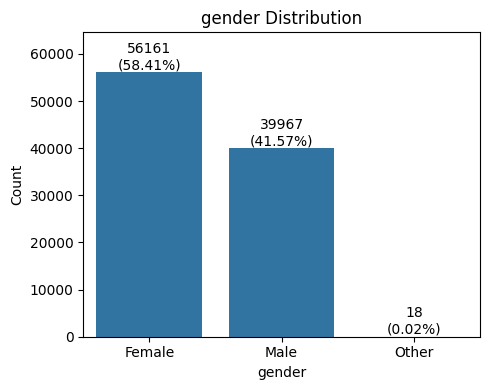

In [58]:
plot_categorical_distribution(diabetes_data, "gender")

The dataset contains three categories: `female` (56,161), `male` (39,967), and `other` (18). The `other` category represents only 0.02% of the data - far too few observations to support any statistically meaningful analysis or for a model to learn a reliable pattern from. Keeping it would effectively be noise rather than signal, and one-hot encoding it would add a column that is almost entirely zeros. For these reasons, the 18 `other` rows are dropped from the dataset.

The remaining two categories are also not evenly distributed: females make up about 58% of the dataset and males about 42%. This imbalance is worth keeping in mind during modeling, though it is far less severe than the target variable's imbalance and does not require a separate correction on its own - it is simply noted here as part of understanding the data.

In [59]:
diabetes_data = diabetes_data[diabetes_data.gender != "Other"].reset_index(drop=True)

In [60]:
print(diabetes_data.gender.unique())

['Female' 'Male']


Since `smoking_history` has many questionable values we need to take a look at it.

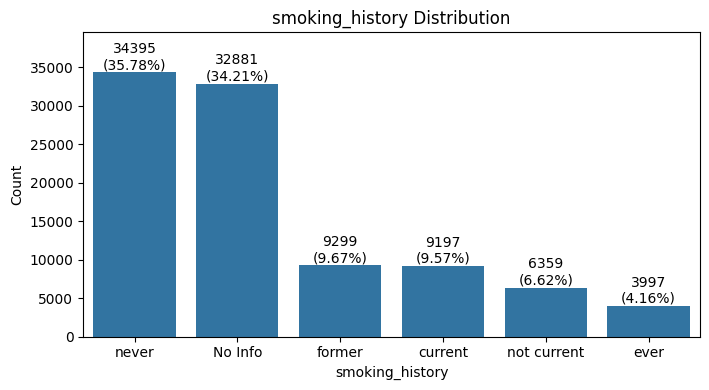

In [61]:
plot_categorical_distribution(diabetes_data, "smoking_history")

The `smoking_history` categories are not mutually exclusive in a fully intuitive way. According to the dataset creator, `former` and `not current` both represent past smokers, differing only in how recently they quit, while `ever` broadly overlaps with both `current` and `former` (anyone who has smoked at any point in their life). This ambiguity has also been noted by other users of the dataset and is treated here as a known limitation of the feature's granularity. The high proportion of `No Info` values (~34% of the dataset) observed here has also been independently reported by other users of the dataset, confirming this is a known and consistent characteristic of the data rather than an artifact specific to this analysis.

Given the overlap between `former`, `not current`, and `ever` described above, these three categories are consolidated into a single `past_smoker` category. This reduces noise introduced by an ambiguous boundary between categories that the dataset's documentation itself does not clearly distinguish, while keeping `never`, `current`, and `No Info` as separate, unambiguous categories.

In [62]:
smoking_map = {
    "never": "never",
    "No Info": "No Info",
    "current": "current",
    "former": "past_smoker",
    "not current": "past_smoker",
    "ever": "past_smoker"
}

diabetes_data.smoking_history = diabetes_data.smoking_history.map(smoking_map)

print(diabetes_data.smoking_history.value_counts())

smoking_history
never          34395
No Info        32881
past_smoker    19655
current         9197
Name: count, dtype: int64


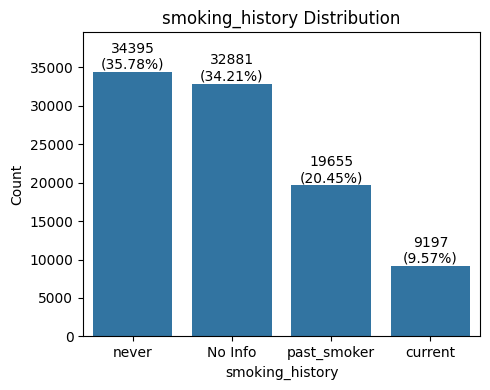

In [63]:
plot_categorical_distribution(diabetes_data, "smoking_history")

Let's proceed with `age`, `bmi`, `blood_glucose_level` and `HbA1c_level`

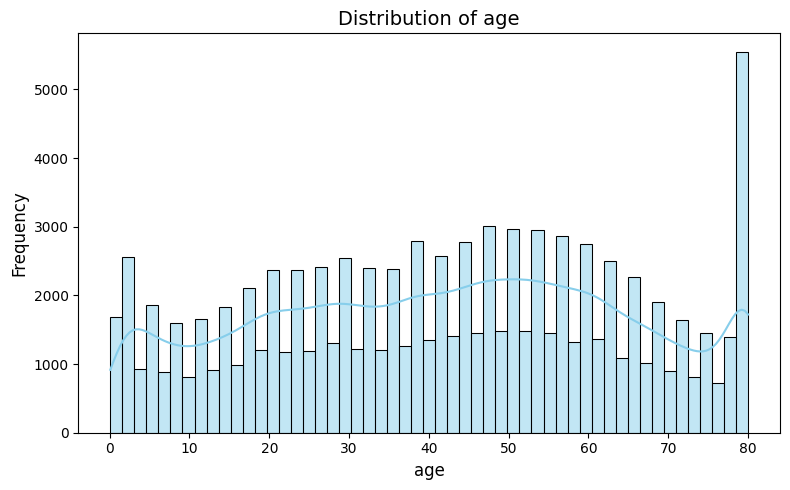

Statistical Measures for age:
count    96128.000000
mean        41.796617
std         22.463329
min          0.080000
25%         24.000000
50%         43.000000
75%         59.000000
max         80.000000
Name: age, dtype: float64


In [64]:
plot_numeric_distribution(diabetes_data, "age")

The `age` column ranges from 0.08 to 80 years (mean ≈ 41.8, median = 43). The minimum value of 0.08 (approximately one month old) is unusual for a diabetes risk dataset, since type 2 diabetes in infants is exceptionally rare - this may reflect synthetic data generation rather than a realistic clinical population. The maximum is capped at exactly 80, visible as a spike in the histogram, suggesting the source data top-codes all ages of 80 and above into a single value rather than recording true age beyond that point. Both observations are noted here as limitations of the dataset's realism, consistent with the earlier findings for `bmi`, `HbA1c_level`, and `blood_glucose_level`.

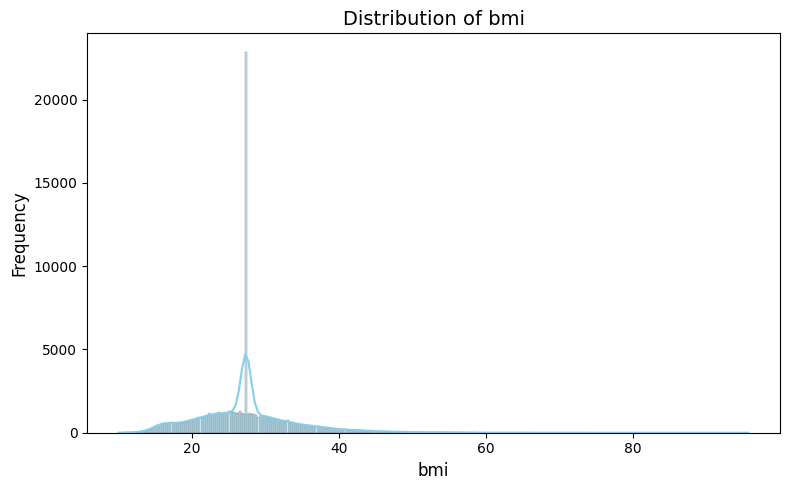

Statistical Measures for bmi:
count    96128.000000
mean        27.321450
std          6.767811
min         10.010000
25%         23.400000
50%         27.320000
75%         29.860000
max         95.690000
Name: bmi, dtype: float64


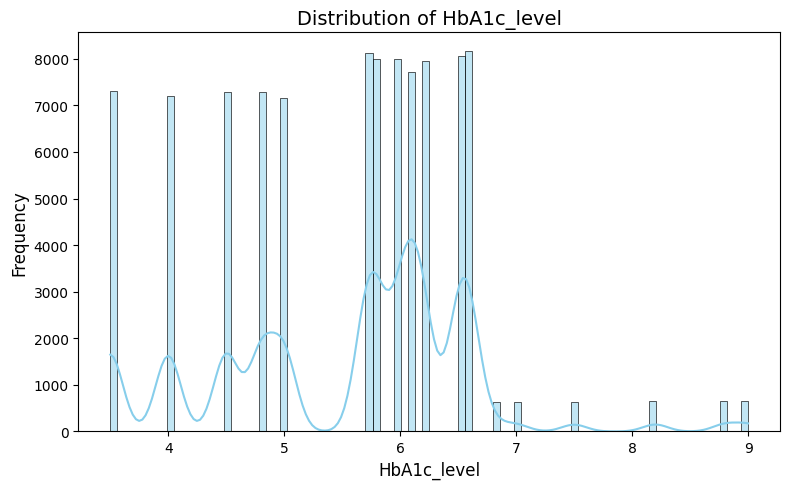

Statistical Measures for HbA1c_level:
count    96128.000000
mean         5.532633
std          1.073225
min          3.500000
25%          4.800000
50%          5.800000
75%          6.200000
max          9.000000
Name: HbA1c_level, dtype: float64


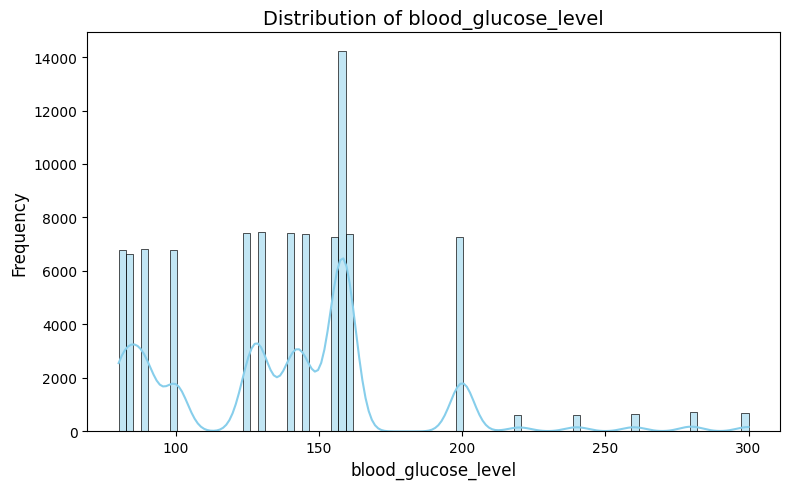

Statistical Measures for blood_glucose_level:
count    96128.000000
mean       138.218001
std         40.911190
min         80.000000
25%        100.000000
50%        140.000000
75%        159.000000
max        300.000000
Name: blood_glucose_level, dtype: float64


In [65]:
plot_numeric_distribution(diabetes_data, "bmi")
plot_numeric_distribution(diabetes_data, "HbA1c_level")
plot_numeric_distribution(diabetes_data, "blood_glucose_level")

In [66]:
print(diabetes_data.bmi.value_counts().head(10))
print(diabetes_data.HbA1c_level.value_counts().head(10))
print(diabetes_data.blood_glucose_level.value_counts().head(10))

bmi
27.32    21659
23.00      103
27.12      101
24.96      100
27.80      100
22.40       99
25.00       99
25.60       98
24.50       94
26.70       94
Name: count, dtype: int64
HbA1c_level
6.6    8161
5.7    8123
6.5    8051
5.8    7992
6.0    7987
6.2    7956
6.1    7712
3.5    7316
4.8    7296
4.5    7289
Name: count, dtype: int64
blood_glucose_level
159    7475
130    7471
126    7419
140    7414
160    7393
145    7371
200    7289
155    7285
90     6820
80     6785
Name: count, dtype: int64


In [67]:
print(f"Unique HbA1c values: {diabetes_data.HbA1c_level.nunique()}")
print(f"Unique glucose values: {diabetes_data.blood_glucose_level.nunique()}")

Unique HbA1c values: 18
Unique glucose values: 18


The `bmi` distribution shows an unusually sharp concentration around a single value: `27.32` appears 21,659 times, accounting for roughly 22.5% of the entire dataset, while every other value appears at most ~100 times. This strongly suggests that a large portion of `bmi` entries were imputed with a single placeholder (likely a population mean or default value) rather than independently measured - a known characteristic of this dataset rather than an artifact of this analysis.

Similarly, `HbA1c_level` and `blood_glucose_level` each take on only 18 unique values across the entire dataset, despite both being continuous physiological measurements in reality. This confirms the earlier visual observation of discrete spikes in their histograms: the underlying data was likely quantized, bucketed, or synthetically generated rather than collected as raw individual lab measurements. This is noted here as a limitation affecting the realism of the dataset, and is relevant context when interpreting the strength of their correlation with the target variable discussed earlier.

Let's plot the heart `disease` and `hypertension` columns

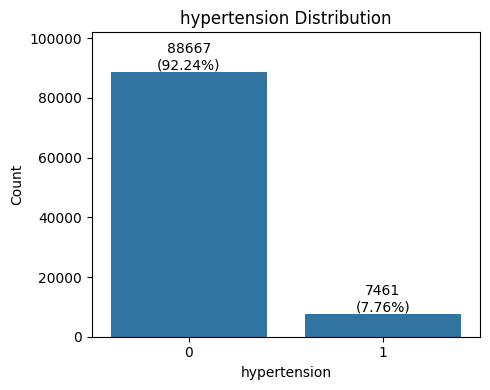

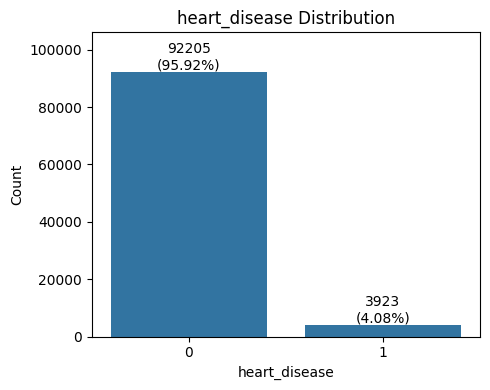

In [68]:
plot_categorical_distribution(diabetes_data, "hypertension")
plot_categorical_distribution(diabetes_data, "heart_disease")

Both `hypertension` and `heart_disease` are highly imbalanced binary features: only 7.76% of respondents report hypertension, and 4.08% report heart disease. These proportions are broadly consistent with real-world population prevalence rates for these conditions, so the imbalance itself is not a data quality concern - unlike `bmi`, `HbA1c_level`, and `blood_glucose_level` discussed above, these values appear plausible rather than synthetic.

Given the outliers observed in `bmi` and the discretized nature of `HbA1c_level` and `blood_glucose_level`, Spearman correlation is used here instead of Pearson. Spearman measures monotonic rather than strictly linear relationships and is more robust to outliers, making it a more appropriate choice given the data quality limitations discussed earlier.

In [69]:
cols_heat_map = ["diabetes", "age", "bmi", "HbA1c_level", "blood_glucose_level", "hypertension", "heart_disease"]

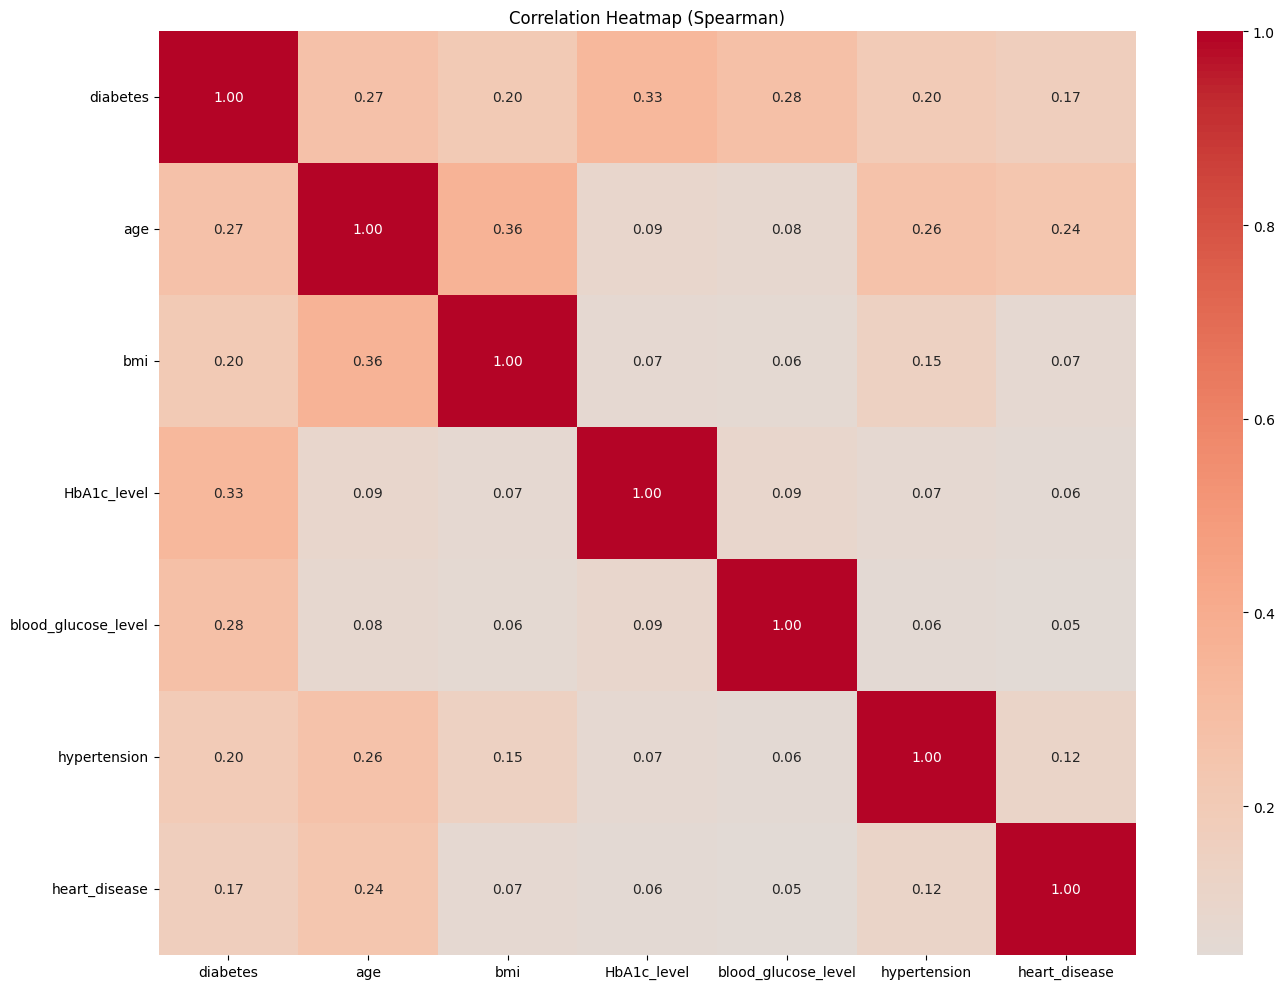

In [70]:
plot_correlation_heatmap(diabetes_data, columns=cols_heat_map, title="Correlation Heatmap (Spearman)")

**Interpretation**

`HbA1c_level` (0.33) and `blood_glucose_level` (0.28) are the two features most strongly correlated with `diabetes`, consistent with them being the clinical diagnostic criteria for the condition rather than independent risk factors, as discussed earlier.

`age` (0.27) shows a moderate correlation with diabetes, in line with type 2 diabetes being more common in older adults. `hypertension` (0.20) and `heart_disease` (0.17) show weaker but non-trivial correlations, consistent with their role as comorbidities rather than direct diagnostic criteria. `bmi` shows the weakest correlation with diabetes among the numeric features (0.20), somewhat lower than might be clinically expected - likely related to the data quality concerns raised earlier regarding the large proportion of placeholder-like `bmi` values.

Among the features themselves, `age` and `bmi` show the strongest inter-feature correlation (0.36), while `hypertension` and `heart_disease` are also moderately correlated with `age` (0.26 and 0.24), reflecting the expected co-occurrence of these conditions with older age rather than any redundancy that would require removing a feature at this stage.

In [71]:
diabetes_data.to_csv("data/processed/diabetes_data_cleaned.csv", index=False)

## EDA - (BRFSS)

In [72]:
zip_files = [
    "data/raw/diabetes_012_health_indicators_BRFSS2015.zip",
]

for zip_path in zip_files:
    unzip_csv(zip_path, "data/processed/")

Successfully extracted files: diabetes_012_health_indicators_BRFSS2015.csv


In [73]:
brfss_dataset = pd.read_csv("data/processed/diabetes_012_health_indicators_BRFSS2015.csv")

In [74]:
brfss_dataset

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
253675,0.0,1.0,1.0,1.0,45.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,5.0,0.0,1.0,5.0,6.0,7.0
253676,2.0,1.0,1.0,1.0,18.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,4.0,0.0,0.0,1.0,0.0,11.0,2.0,4.0
253677,0.0,0.0,0.0,1.0,28.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,2.0,5.0,2.0
253678,0.0,1.0,0.0,1.0,23.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,7.0,5.0,1.0


We repeat the duplicate detection procedure applied to the first dataset. Given that most BRFSS features are binary or low-cardinality ordinal values, a higher rate of exact-row duplicates is expected compared to the previous dataset.

In [75]:
duplicate_rows, summary, group_cols = find_duplicates(brfss_dataset, subset=None)
group_sizes = duplicate_rows.groupby(group_cols).size()

print(group_sizes.value_counts().sort_index())

Rows involved in duplication: 35086
Duplicate rows to remove: 23899 (9.42%)
Unique duplicate groups: 11187
2     7219
3     1882
4      790
5      372
6      248
7      159
8      107
9       71
10      41
11      59
12      32
13      28
14      21
15      15
16      19
17      10
18      14
19      12
20       7
21       7
22      10
23       6
24       8
25       4
26       3
27       3
28       3
29       5
30       2
31       3
32       5
34       3
36       2
37       1
39       1
42       3
43       3
44       1
47       1
50       1
51       1
52       2
53       1
55       1
59       1
Name: count, dtype: int64


In [76]:
subset_cols = [c for c in brfss_dataset.columns if c != "Diabetes_012"]
duplicate_rows, summary, group_cols = find_duplicates(brfss_dataset, subset=subset_cols)

Rows involved in duplication: 38000
Duplicate rows to remove: 25772 (10.16%)
Unique duplicate groups: 12228


A large share of rows are exact duplicates. This is expected given the dataset's structure: most features are binary, `BMI` has been rounded to one decimal place in the original, and `Age` is recorded as an age group rather than a precise value - all of which substantially reduce the number of distinct possible rows.

Before proceeding, we verify the original methodology's known limitations directly on this dataset: that `Age` is recorded as a 5-year age group rather than a precise value, and that `BMI` has been rounded to a whole number.

In [77]:
brfss_dataset.Age.value_counts(dropna=False).sort_index()

Age
1.0      5700
2.0      7598
3.0     11123
4.0     13823
5.0     16157
6.0     19819
7.0     26314
8.0     30832
9.0     33244
10.0    32194
11.0    23533
12.0    15980
13.0    17363
Name: count, dtype: int64

In [78]:
print(brfss_dataset.BMI.dtype)
print(brfss_dataset.BMI.value_counts(dropna=False).sort_index())

float64
BMI
12.0      6
13.0     21
14.0     41
15.0    132
16.0    348
       ... 
91.0      1
92.0     32
95.0     12
96.0      1
98.0      7
Name: count, Length: 84, dtype: int64


In [79]:
print((brfss_dataset.BMI % 1 == 0).all())

True


The `cleanup.ipynb` notebook follows the original authors' data cleaning pipeline step by step. The only two deviations introduced here are: (1) retaining unrounded `BMI` values rather than rounding to the nearest integer, and (2) replacing the `_AGEG5YR` age-group column with `_AGE80`, which records continuous age up to 80. These changes preserve more granularity in both features while keeping the overall shape and column structure of the dataset identical to the original.

In [80]:
brfss_2015_dataset = pd.read_csv("data/processed/diabetes_012_health_indicators_BRFSS2015_clean.csv")

In [81]:
brfss_2015_dataset

,diabetes_012,high_blood_pressure,high_cholesterol,chol_checked_recently,bmi,smoked_at_least_100_cigarettes,had_stroke,heart_disease_or_attack,physically_active,consumes_fruit_daily,...,has_healthcare_coverage,skipped_doctor_due_to_cost,general_health,mental_health_bad_days,physical_health_bad_days,difficulty_walking,sex,age,education_level,income_level
0,0.0,1.0,1.0,1.0,40.18,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,63.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.09,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,52.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.19,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,63.0,4.0,8.0
3,0.0,1.0,0.0,1.0,26.52,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,73.0,3.0,6.0
4,0.0,1.0,1.0,1.0,23.89,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,70.0,5.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
253675,0.0,1.0,1.0,1.0,45.00,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,5.0,0.0,1.0,42.0,6.0,7.0
253676,2.0,1.0,1.0,1.0,18.42,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,4.0,0.0,0.0,1.0,0.0,72.0,2.0,4.0
253677,0.0,0.0,0.0,1.0,28.34,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,29.0,5.0,2.0
253678,0.0,1.0,0.0,1.0,23.15,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,52.0,5.0,1.0


In [82]:
duplicate_rows, summary, group_cols = find_duplicates(brfss_2015_dataset, subset=None)
group_sizes = duplicate_rows.groupby(group_cols).size()

print(group_sizes.value_counts().sort_index())

Rows involved in duplication: 2292
Duplicate rows to remove: 1190 (0.47%)
Unique duplicate groups: 1102
2    1019
3      79
4       3
5       1
Name: count, dtype: int64


In [83]:
subset_cols = [c for c in brfss_2015_dataset.columns if c != "diabetes_012"]
duplicate_rows, summary, group_cols = find_duplicates(brfss_2015_dataset, subset=subset_cols)

Rows involved in duplication: 2411
Duplicate rows to remove: 1252 (0.49%)
Unique duplicate groups: 1159


In [84]:
brfss_2015_dataset = remove_duplicates(brfss_2015_dataset)

Rows before: 253680
Rows after: 252490
Removed: 1190


Retaining unrounded `BMI` values and replacing the age-group column with continuous age significantly reduces the duplication rate, confirming that the discretization introduced during the original cleaning was the primary driver of duplicate rows.

Let's now begin with the inspection of the two columns we changed from the originals.

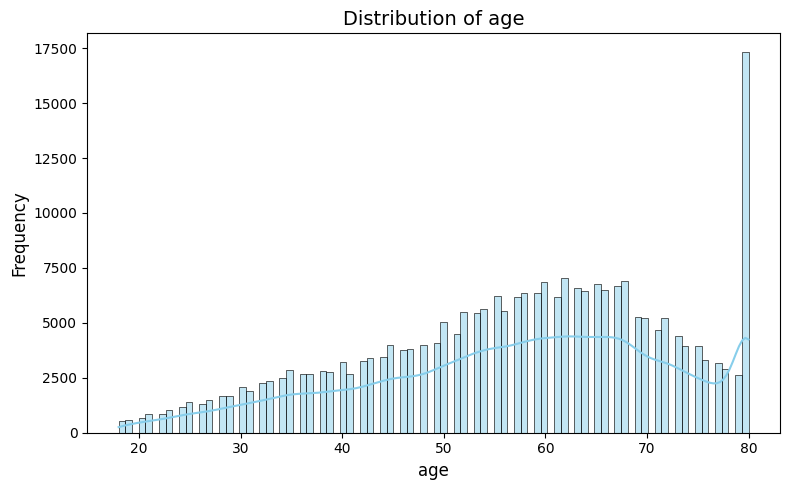

Statistical Measures for age:
count    252490.000000
mean         57.022967
std          15.096255
min          18.000000
25%          47.000000
50%          59.000000
75%          68.000000
max          80.000000
Name: age, dtype: float64


In [85]:
plot_numeric_distribution(brfss_2015_dataset, "age")

The `age` distribution again shows a pronounced spike at 80. This is consistent with the dataset documentation: all respondents aged 80 or above are top-coded to 80, so the spike reflects a real aggregation of older adults rather than a data error. This same pattern was observed in the previous dataset and is treated as a known structural property of both sources rather than a quality concern.

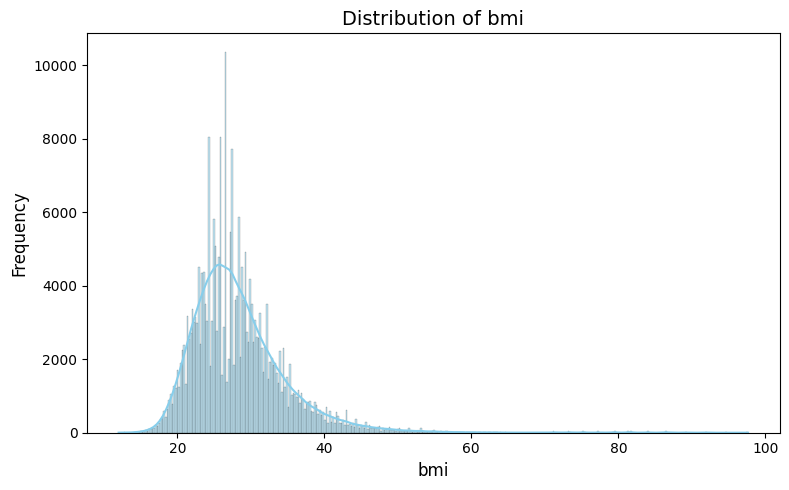

Statistical Measures for bmi:
count    252490.000000
mean         28.415001
std           6.609721
min          12.020000
25%          24.190000
50%          27.370000
75%          31.320000
max          97.650000
Name: bmi, dtype: float64


In [86]:
plot_numeric_distribution(brfss_2015_dataset, "bmi")

**`bmi`** follows a roughly right-skewed distribution with a realistic spread, unlike the artificial spike at 27.32 observed in the previous dataset. This suggests the unrounded `bmi` values here are more representative of genuine individual measurements, with no evidence of systematic imputation with a placeholder value.

In [87]:
category_columns = [
    "high_blood_pressure",
    "high_cholesterol",
    "chol_checked_recently",
    "smoked_at_least_100_cigarettes",
    "had_stroke",
    "heart_disease_or_attack",
    "physically_active",
    "consumes_fruit_daily",
    "consumes_veggies_daily",
    "heavy_alcohol_consumption",
    "has_healthcare_coverage",
    "skipped_doctor_due_to_cost",
    "general_health",
    "difficulty_walking",
    "sex",
    "education_level",
    "income_level",
    "mental_health_bad_days",
    "physical_health_bad_days"
]

We now inspect the distribution of all categorical features in the cleaned BRFSS dataset.

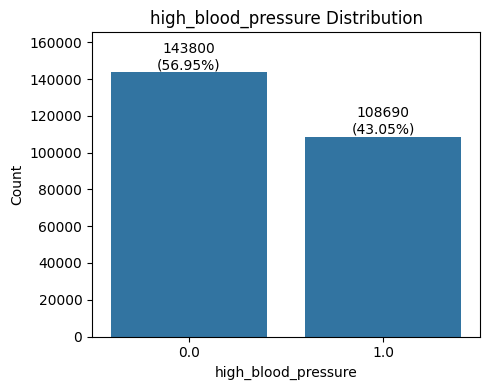

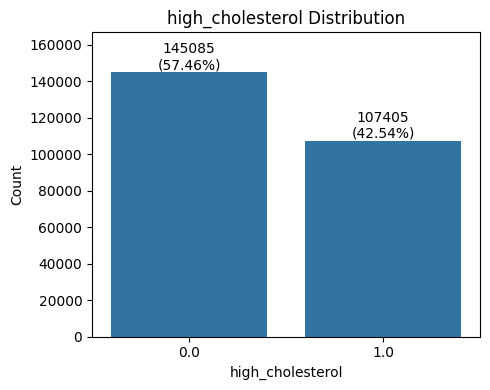

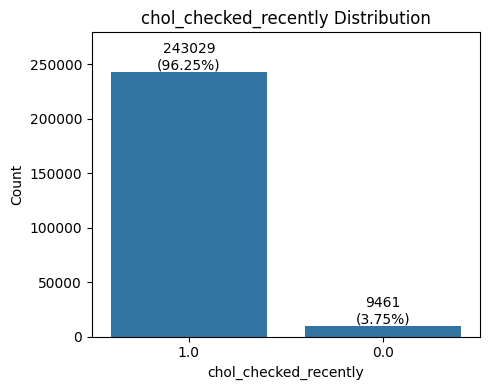

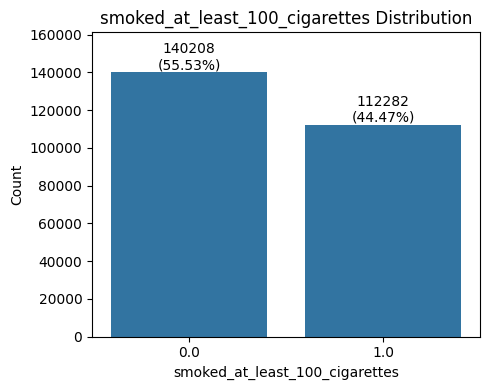

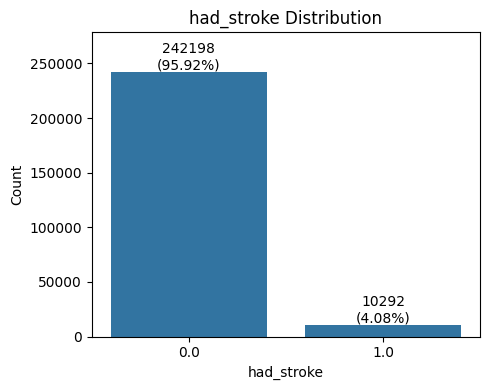

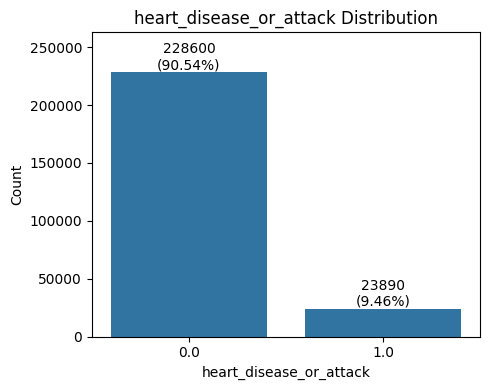

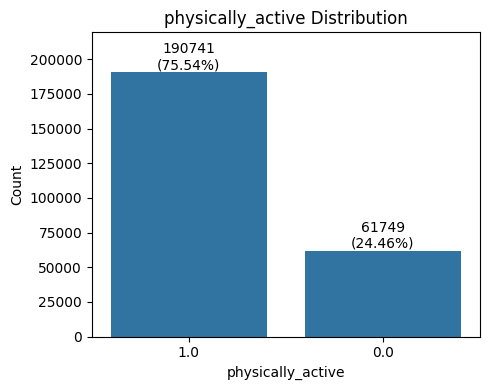

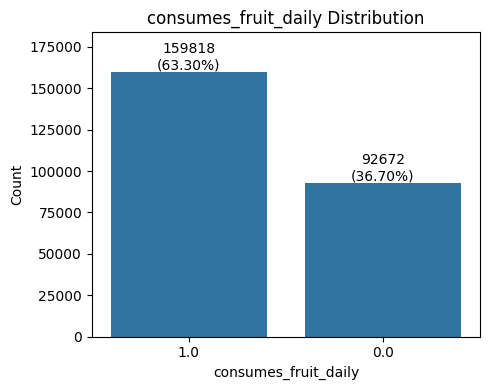

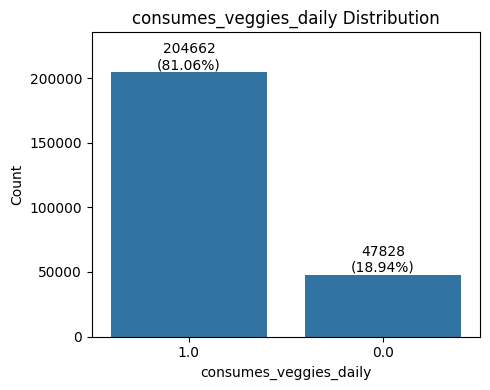

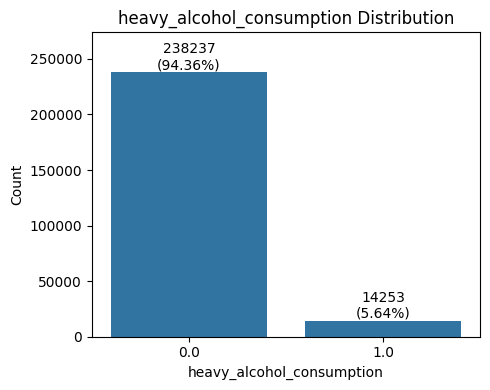

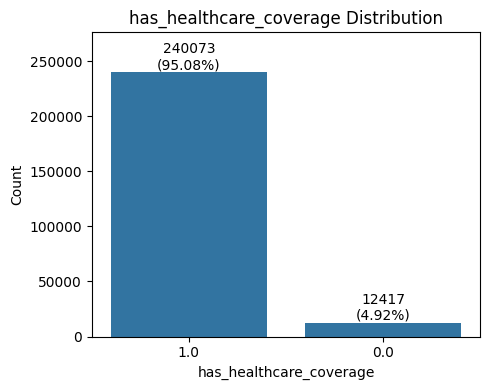

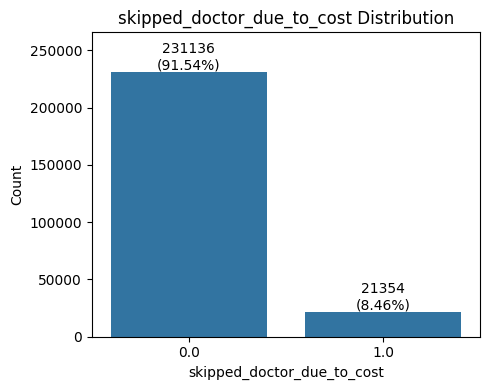

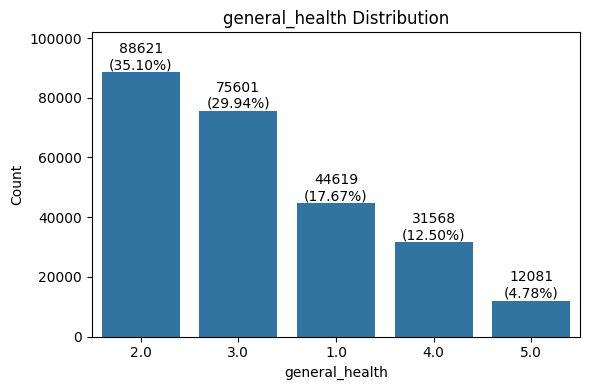

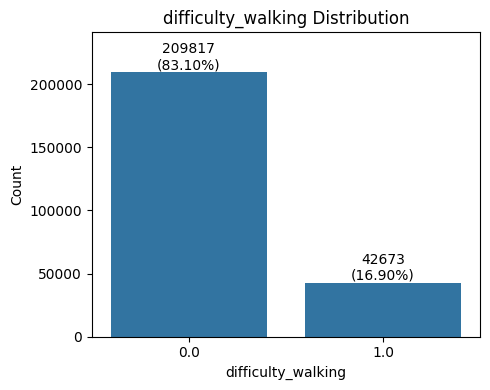

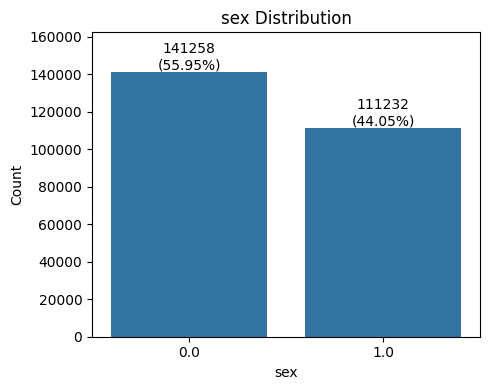

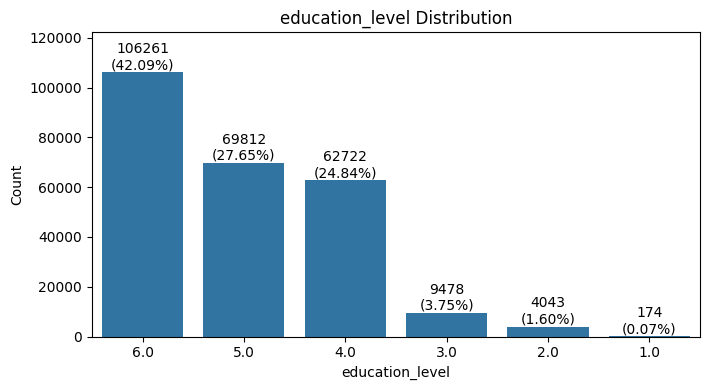

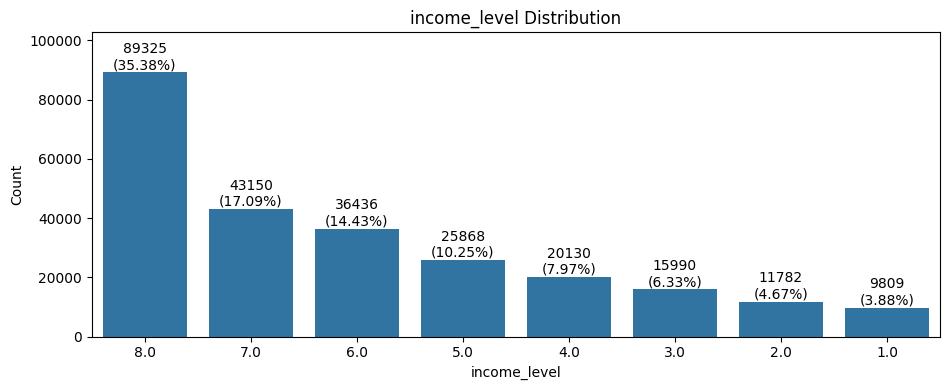

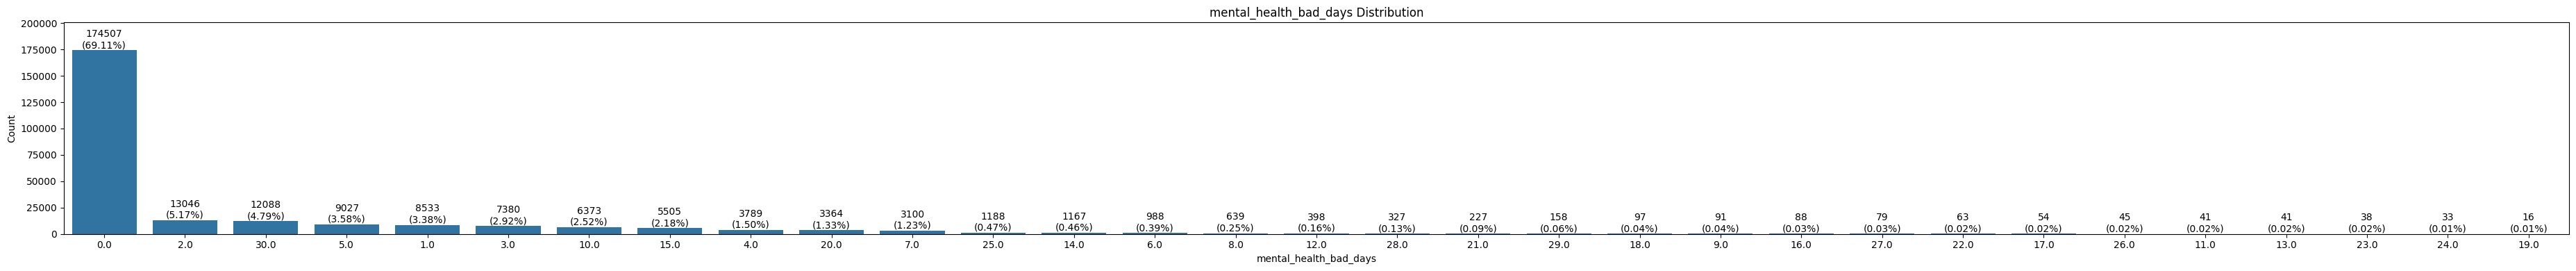

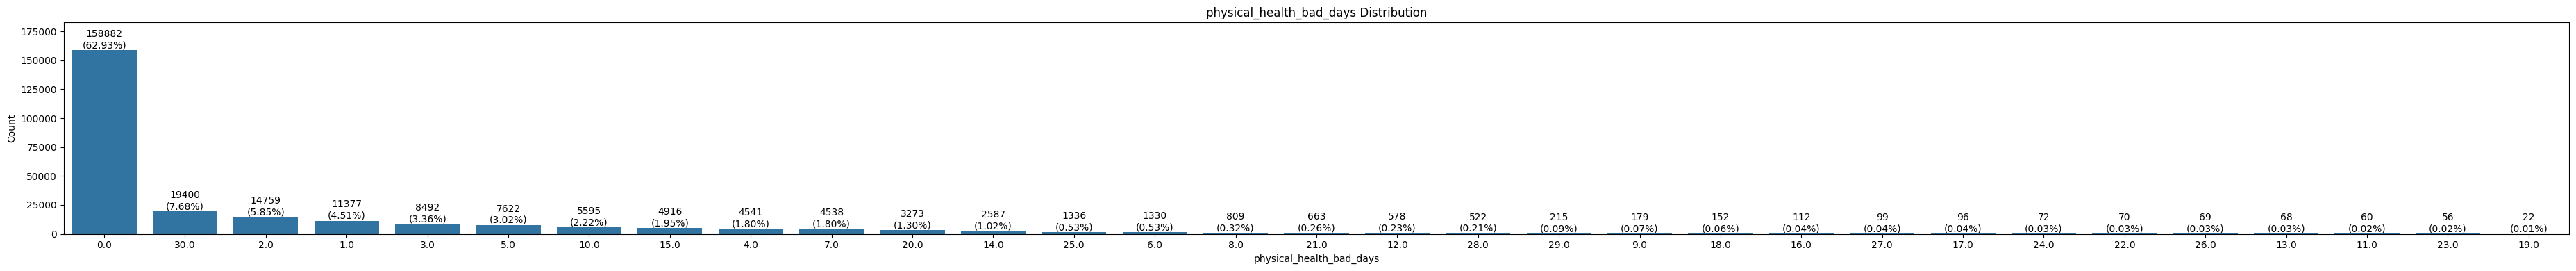

[None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None]

In [88]:
[plot_categorical_distribution(brfss_2015_dataset, col) for col in category_columns]

The categorical features show varying degrees of class imbalance:

- **`had_stroke`** (4.08%) and **`heart_disease_or_attack`** (9.46%) are rare events, consistent with general population prevalence rates. Their low positive rates make them weak standalone predictors but potentially informative in combination with other features.
- **`has_healthcare_coverage`** (95.08% positive) and **`chol_checked_recently`** (96.25% positive) are near-constant - nearly all respondents report having coverage and having had a recent cholesterol check. These features carry very little discriminative information and are strong candidates for removal during feature selection.
- **`heavy_alcohol_consumption`** (5.64% positive) is rare and likely to have limited predictive power on its own.
- **`general_health`** is the only ordinal non-binary feature, with scores ranging from 1 (excellent) to 5 (poor). Most respondents report good to very good health (categories 2–3), with fewer reporting poor health (category 5). This feature is expected to correlate meaningfully with the diabetes indicator.
- **`education_level`** and **`income_level`** both show right-skewed distributions, with most respondents concentrated in the higher brackets.

With the distributions examined, we now compute Spearman correlations across all features to identify which variables are most strongly associated with the diabetes indicator and with each other.

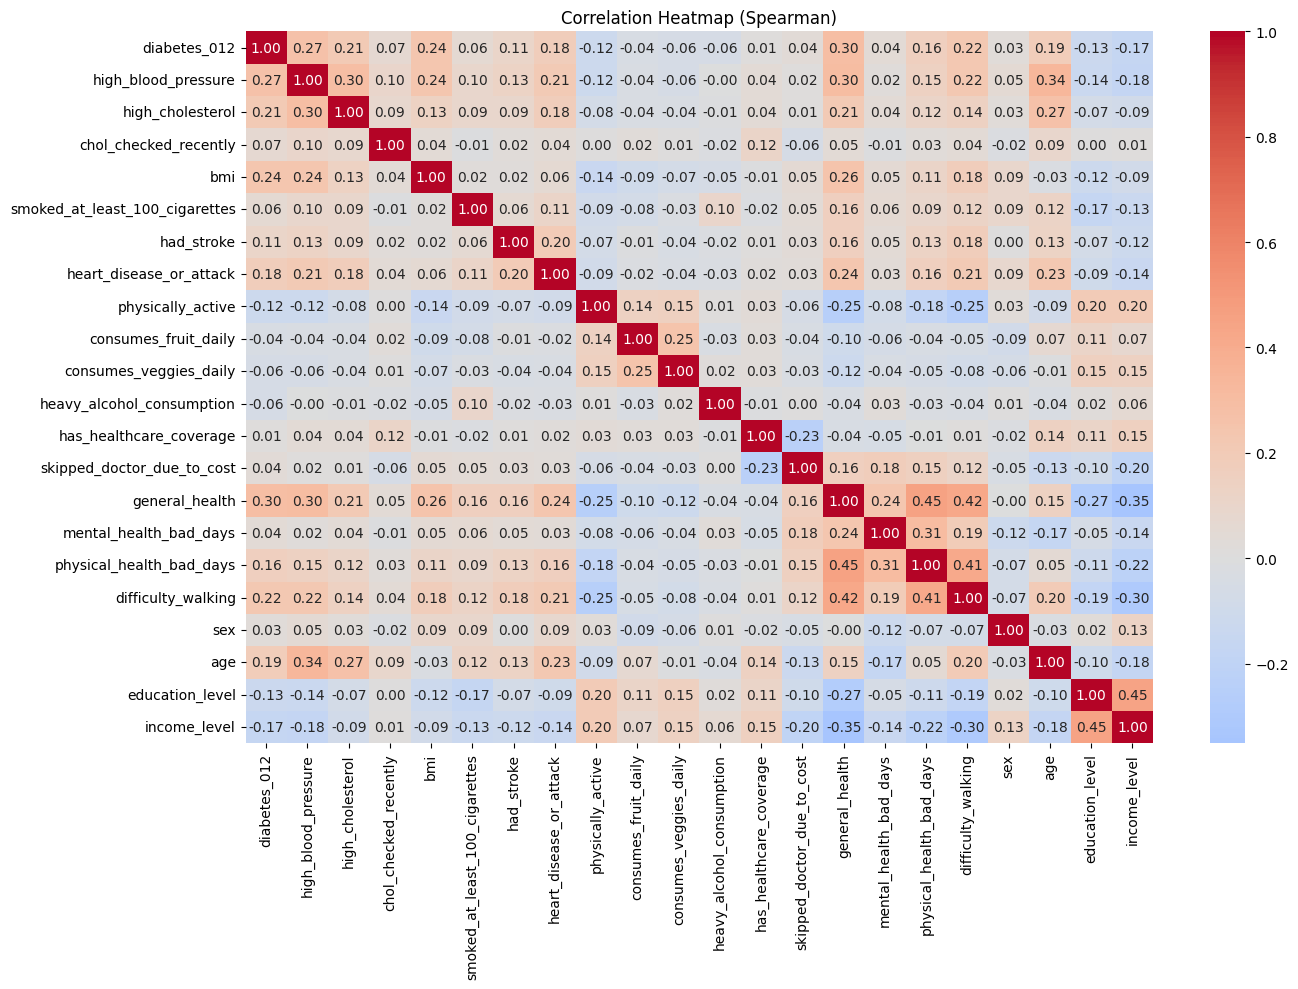

In [89]:
plot_correlation_heatmap(brfss_2015_dataset, title="Correlation Heatmap (Spearman)")

The Spearman correlation matrix reveals the following patterns:

**Strongest correlations with `diabetes_012`:**
- `general_health` (0.30) - self-reported poor health is the single strongest correlation of diabetes in this dataset, likely acting as a proxy for multiple underlying conditions simultaneously.
- `high_blood_pressure` (0.27) and `bmi` (0.24) - both established clinical risk factors, showing the expected moderate association.
- `difficulty_walking` (0.22) and `heart_disease_or_attack` (0.18) - consistent with diabetes being a systemic condition with cardiovascular and mobility consequences.

**Notable inter-feature correlations:**
- `general_health` correlates moderately with `mental_health_bad_days` (0.24), `physical_health_bad_days` (0.45), and `difficulty_walking` (0.42), reflecting that self-reported overall health is a composite of these more specific measures.
- `physical_health_bad_days` and `difficulty_walking` (0.41) are themselves correlated, which is clinically expected.
- `education_level` and `income_level` (0.45) show the strongest inter-feature correlation in the matrix, reflecting the well-documented socioeconomic relationship between the two.
- `income_level` shows a moderate negative correlation with `diabetes_012` (−0.17), consistent with lower-income populations facing higher diabetes risk due to reduced access to healthcare, healthy food, and physical activity opportunities.

**Weak or negligible correlations:**
- `heavy_alcohol_consumption`, `consumes_fruit_daily`, `consumes_veggies_daily`, and `sex` all show correlations near zero with `diabetes_012`, suggesting limited direct predictive value when considered individually.

We deliberately left the `diabetes_012` for last. The original dataset has a variant where the `1.0` category is combined with `0.0` because of its skewness.

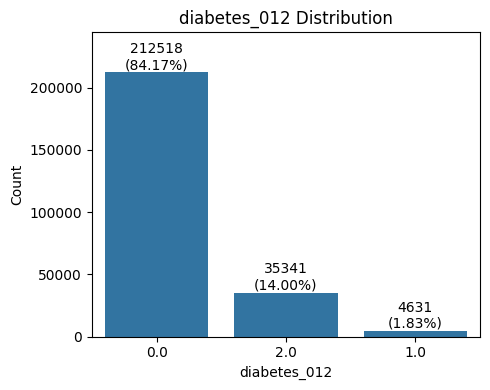

In [90]:
plot_categorical_distribution(brfss_2015_dataset, "diabetes_012")

`diabetes_012` is heavily skewed: 84.17% of respondents have no diabetes, 14.00% have diabetes, and only 1.83% have prediabetes. This severe imbalance must be addressed - a naive classifier predicting "no diabetes" would achieve 84% accuracy while being clinically useless. The solution proposed in the original dataset makes sense to some extent: people with prediabetes do not have diabetes - yet. The key word here is "yet". Depending on our goal for the model, we may prefer prediabetes to be classified together with diabetes instead. Let's compare the `1.0` category to the other two, and decide whether to combine it with another class or drop it entirely.

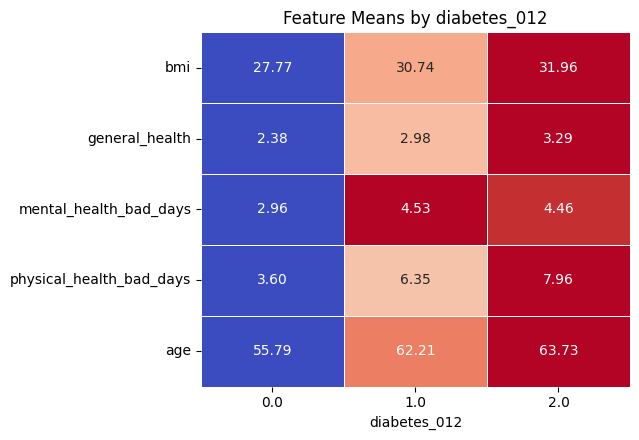

In [91]:
numeric_features = ["bmi", "general_health", "mental_health_bad_days", 
                     "physical_health_bad_days", "age"] 

plot_group_means_heatmap(brfss_2015_dataset, "diabetes_012", numeric_features)

`bmi`, `general_health`, `mental_health_bad_days`, `physical_health_bad_days`, and `age` all increase from class 0 to class 2, with prediabetes (class 1) sitting in between. However, prediabetes is consistently closer to diabetes than to no-diabetes: for example, `age` moves from 55.8 (no diabetes) to 62.2 (prediabetes) - a jump of 6.4 years - but only rises a further 1.5 years to reach diabetes (63.7). The same pattern holds for `bmi`, `general_health`, and `physical_health_bad_days`. `mental_health_bad_days` is a notable exception: prediabetes (4.53) is actually slightly higher than diabetes (4.46), rather than falling in between - the only feature here that does not increase monotonically across the three classes.

In [92]:
excluded = ["bmi", "general_health", "mental_health_bad_days", "physical_health_bad_days", "age", "diabetes_012"]

category_columns = [col for col in category_columns if col not in excluded]

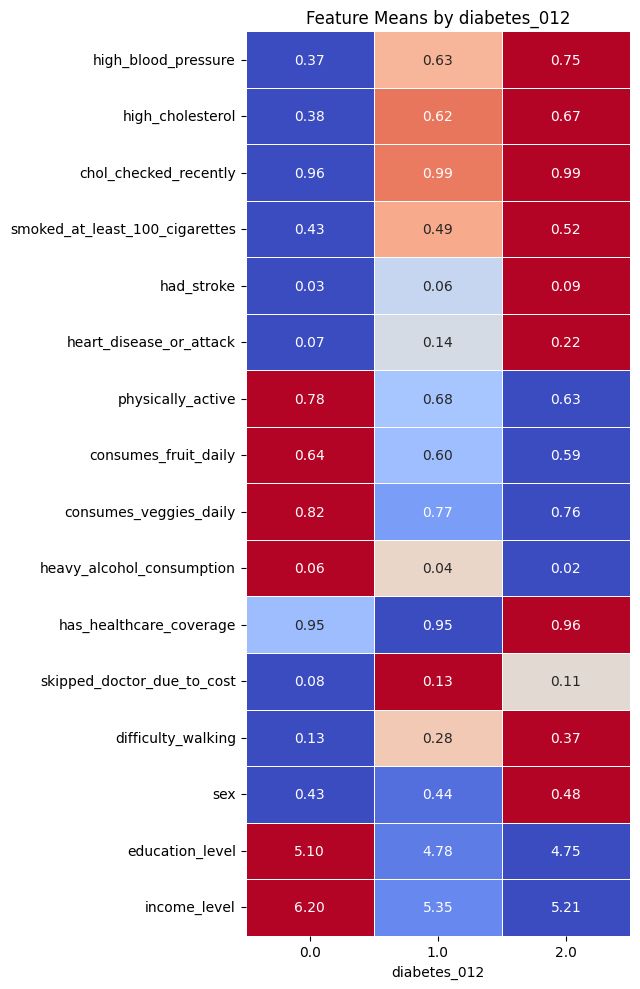

In [93]:
plot_group_means_heatmap(brfss_2015_dataset, "diabetes_012", category_columns)

Most features follow the same pattern as above: `high_blood_pressure`, `high_cholesterol`, `heart_disease_or_attack`, `difficulty_walking`, and the diet/activity indicators (`physically_active`, `consumes_fruit_daily`, `consumes_veggies_daily`) all place prediabetes closer to diabetes than to no-diabetes. `income_level` and `education_level` show the same pattern in the negative direction (both decrease from class 0 to class 2, with prediabetes closer to the diabetic end).

Two features break this pattern: `skipped_doctor_due_to_cost` peaks at prediabetes (0.13) rather than continuing to rise into diabetes (0.11), and `heart_disease_or_attack`/`had_stroke` show only marginal differences between classes 1 and 0. A plausible explanation for the `skipped_doctor_due_to_cost` reversal is that prediabetes represents a period of diagnostic uncertainty - elevated awareness of risk without an established, routine course of treatment - whereas diagnosed diabetics may have more consistent, budgeted healthcare engagement.

The heatmaps above compare only the *mean* value of each feature across classes. A mean-based comparison has two limitations: (1) it says nothing about whether an observed difference is statistically robust or could plausibly arise from random sampling variation, and (2) it gives no sense of the *magnitude* of a difference relative to the natural spread of the data - a difference in means can look large or small depending on the scale of the feature, without a standardized way to compare across features.

The Mann-Whitney U test addresses the first limitation by directly testing whether one group's values are stochastically greater than another's, without assuming a normal distribution (appropriate here given the skewed, partly discrete nature of features like `mental_health_bad_days`). However, with a sample size in the hundreds of thousands, the p-value alone becomes uninformative - almost any nonzero difference reaches statistical significance regardless of its practical relevance. The accompanying rank-biserial effect size solves this by quantifying *how large* the difference actually is, independent of sample size.

Finally, the centroid distance test summarizes all features jointly into a single number per comparison, using standardized (scaled) values so that features on different scales contribute comparably. This provides a concise, single-metric confirmation that supports the same conclusion as the per-feature comparisons above, rather than requiring the reader to mentally aggregate multiple individual effect sizes.

Together, these three levels of analysis - descriptive means, statistical significance with effect size, and a summary distance metric - provide increasingly rigorous, complementary evidence for the same conclusion: prediabetes is more similar to diagnosed diabetes than to the absence of diabetes, supporting the decision to merge it with the diabetic class when constructing the binary target.

In [94]:
# statistical comparison with effect size
results_01 = compare_groups_mannwhitney(brfss_2015_dataset, "diabetes_012", numeric_features, group_a=1, group_b=0)
results_12 = compare_groups_mannwhitney(brfss_2015_dataset, "diabetes_012", numeric_features, group_a=1, group_b=2)

comparison = results_01.merge(results_12, on="feature", suffixes=("_vs_0", "_vs_2"))
print(comparison)

                    feature   p_value_vs_0  effect_size_vs_0  p_value_vs_2  \
0                       bmi  7.927031e-249            -0.289  2.566525e-30   
1            general_health   0.000000e+00            -0.318  3.114401e-83   
2    mental_health_bad_days   1.056359e-27            -0.076  1.058062e-02   
3  physical_health_bad_days   2.788720e-97            -0.152  5.571753e-20   
4                       age  3.090460e-174            -0.241  8.777681e-10   

   effect_size_vs_2  
0             0.103  
1             0.167  
2            -0.019  
3             0.078  
4             0.055  


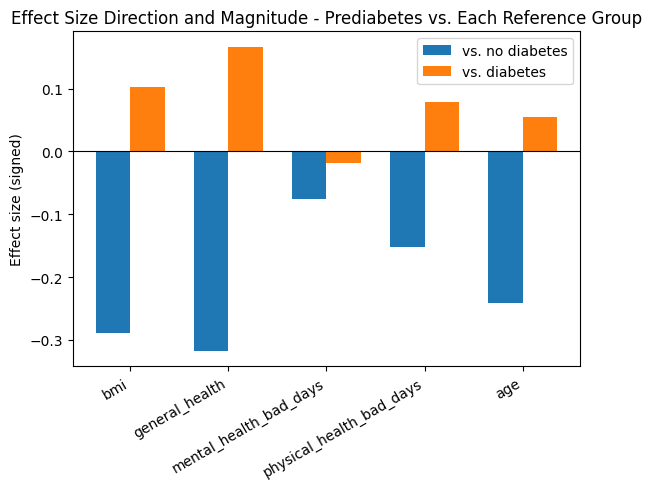

In [95]:
plot_effect_size_comparison(comparison)

The chart plots signed effect sizes rather than absolute values, so direction is preserved. For a feature that increases monotonically across the three ordered classes (no diabetes $ \rightarrow $ prediabetes $ \rightarrow $ diabetes), the two bars are expected to point in opposite directions: the blue bar (vs. no-diabetes) negative, meaning prediabetes values are higher than no-diabetes, and the orange bar (vs. diabetes) positive, meaning prediabetes values are still lower than diabetes. This opposite-direction pattern holds for four of the five features (`bmi`, `general_health`, `physical_health_bad_days`, `age`), and in each case the orange bar is visibly shorter than the blue bar - confirming that prediabetes sits closer to the diabetic end of the distribution than to the non-diabetic end.

`mental_health_bad_days` is the exception: both bars point in the same (negative) direction, meaning prediabetes reports higher values than *both* no-diabetes and diabetes, rather than falling in between them. Its corresponding p-value against diabetes (0.011) is also far less extreme than for the other features, closer to the conventional significance threshold - indicating a comparatively weaker and directionally different signal for this specific feature.

In [96]:
dist_1_0 = compare_group_centroids(brfss_2015_dataset, "diabetes_012", numeric_features, group_a=1, group_b=0)
dist_1_2 = compare_group_centroids(brfss_2015_dataset, "diabetes_012", numeric_features, group_a=1, group_b=2)

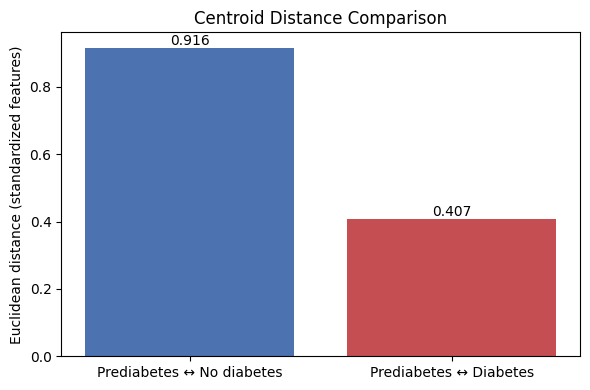

In [97]:
plot_centroid_distances({
    "Prediabetes ↔ No diabetes": dist_1_0,
    "Prediabetes ↔ Diabetes": dist_1_2
})

P-values against no-diabetes are extremely small across all features (several below 1e-100), but at this sample size (n > 250,000) this reflects the statistical power of the test rather than practical significance - this is precisely why effect size, not the p-value, is used to draw the main conclusions here.

The centroid distance chart summarizes all features jointly into a single number per comparison: the distance between prediabetes and no-diabetes (0.916) is more than double the distance between prediabetes and diabetes (0.407), consistent with the overall pattern above.

Taken together, these results support merging prediabetes with the diabetic class when constructing the binary target, rather than following the original methodology's choice of merging it with the non-diabetic class - while acknowledging that this relationship is not uniform across every individual feature.

In [98]:
diabetes_binary_map = {
    0: 0,  # no diabetes stays 0
    1: 1,  # prediabetes merged into the "at-risk / diabetic" class
    2: 1   # diabetes stays 1
}

brfss_2015_dataset.diabetes_012 = brfss_2015_dataset.diabetes_012.map(diabetes_binary_map)

brfss_2015_dataset = brfss_2015_dataset.rename(columns={"diabetes_012": "diabetes"})

print(brfss_2015_dataset.diabetes.value_counts())
print(brfss_2015_dataset.diabetes.value_counts(normalize=True) * 100)

diabetes
0    212518
1     39972
Name: count, dtype: int64
diabetes
0    84.168878
1    15.831122
Name: proportion, dtype: float64


In [99]:
brfss_2015_dataset

,diabetes,high_blood_pressure,high_cholesterol,chol_checked_recently,bmi,smoked_at_least_100_cigarettes,had_stroke,heart_disease_or_attack,physically_active,consumes_fruit_daily,...,has_healthcare_coverage,skipped_doctor_due_to_cost,general_health,mental_health_bad_days,physical_health_bad_days,difficulty_walking,sex,age,education_level,income_level
0,0,1.0,1.0,1.0,40.18,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,63.0,4.0,3.0
1,0,0.0,0.0,0.0,25.09,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,52.0,6.0,1.0
2,0,1.0,1.0,1.0,28.19,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,63.0,4.0,8.0
3,0,1.0,0.0,1.0,26.52,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,73.0,3.0,6.0
4,0,1.0,1.0,1.0,23.89,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,70.0,5.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
252485,0,1.0,1.0,1.0,45.00,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,5.0,0.0,1.0,42.0,6.0,7.0
252486,1,1.0,1.0,1.0,18.42,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,4.0,0.0,0.0,1.0,0.0,72.0,2.0,4.0
252487,0,0.0,0.0,1.0,28.34,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,29.0,5.0,2.0
252488,0,1.0,0.0,1.0,23.15,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,52.0,5.0,1.0


In [100]:
brfss_2015_dataset.to_csv("data/processed/BRFSS2015_binary_data_cleaned.csv", index=False)

## Preprocessing - Clinical

### Load data

In [101]:
diabetes_data = pd.read_csv("data/processed/diabetes_data_cleaned.csv")

In [102]:
diabetes_data

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0
...,...,...,...,...,...,...,...,...,...
96123,Female,36.0,0,0,No Info,24.60,4.8,145,0
96124,Female,2.0,0,0,No Info,17.37,6.5,100,0
96125,Male,66.0,0,0,past_smoker,27.83,5.7,155,0
96126,Female,24.0,0,0,never,35.42,4.0,100,0


### Train/Test Split

We start with the splitting of the data into training and testing split. This is done before the encoding and the scaling in order to avoid data leakage.

In [103]:
X = diabetes_data.drop(columns=["diabetes"])
y = diabetes_data["diabetes"]

In [104]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [105]:
print(f"Train shape: {X_train.shape}, positive rate: {y_train.mean():.4f}")
print(f"Test shape: {X_test.shape}, positive rate: {y_test.mean():.4f}")

Train shape: (76902, 8), positive rate: 0.0882
Test shape: (19226, 8), positive rate: 0.0882


### Encoding

This dataset does not need much encoding. Only the `gender` and `smoking_history` will need to be encoded using one-hot-encoding.

`gender` and `smoking_history` are both nominal categorical variables - there is no inherent order between their categories, so one-hot encoding is used instead of ordinal/label encoding, which would otherwise imply a false ranking.

`smoking_history` in particular cannot be meaningfully treated as ordinal: besides the ambiguity between `never`, `current`, and `past_smoker` (a long-quit light smoker vs a current heavy smoker do not have an obvious risk ordering), the category also includes `No Info`, which represents missing data rather than a smoking status and therefore has no valid position on any risk scale. This was already noted in the EDA section.

### Scaling

The EDA notebook showed that the four numeric features do not all share the same distribution shape. `bmi` is heavily concentrated around a single value with a long tail of extreme outliers, and `blood_glucose_level` shows a similar, though milder, tail of higher values beyond its main discretized range. `age` and `HbA1c_level` show no comparable outlier-driven tail.

Because of this, two different scalers are used: `RobustScaler` for `bmi` and `blood_glucose_level`, since it scales using the median and interquartile range rather than the mean and standard deviation, making it less sensitive to the outliers identified in these two features. `StandardScaler` is used for `age` and `HbA1c_level`, where no such outlier concern 
applies.

Scaling matters mainly for Logistic Regression, since its regularization term penalizes coefficients on a comparable basis regardless of a feature's natural numeric range. Random Forest is scale-invariant, so scaling does not affect them, but the same scaled features are reused for all models for simplicity. `hypertension` and `heart_disease` are left unscaled, since their 0/1 values already represent category membership rather than a quantity. The same applies to `gender` and `smoking_history` one-hot encoded below.

### Applying Encoding and Scaling Together

Encoding and scaling are combined into a single `make_column_transformer`, so both are fit once on the training data and applied consistently to the test data in one step. The transformer is fit only on `X_train` (`fit_transform`) and only applied - not re-fit - on `X_test` (`transform`), so that no information from the test set (category frequencies, scaling statistics) leaks into the preprocessing.

In [106]:
categorical_cols = ["gender", "smoking_history"]
robust_cols = ["bmi", "blood_glucose_level"]
standard_cols = ["age", "HbA1c_level"]

In [107]:
preprocessor = make_column_transformer(
    (OneHotEncoder(), categorical_cols),
    (RobustScaler(), robust_cols),
    (StandardScaler(), standard_cols),
    remainder="passthrough",
    verbose_feature_names_out=False
)

In [108]:
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

In [109]:
feature_names = preprocessor.get_feature_names_out()
X_train_transformed = pd.DataFrame(X_train_transformed, columns=feature_names, index=X_train.index)
X_test_transformed = pd.DataFrame(X_test_transformed, columns=feature_names, index=X_test.index)

In [110]:
X_train_transformed

,gender_Female,gender_Male,smoking_history_No Info,smoking_history_current,smoking_history_never,smoking_history_past_smoker,bmi,blood_glucose_level,age,HbA1c_level,hypertension,heart_disease
12239,1.0,0.0,0.0,0.0,1.0,0.0,-0.494590,-0.677966,-0.879517,0.528048,0.0,0.0
50857,1.0,0.0,0.0,0.0,0.0,1.0,0.174652,2.033898,1.210443,3.231685,0.0,1.0
61036,0.0,1.0,0.0,0.0,1.0,0.0,-1.027821,1.016949,-0.479312,0.994193,0.0,0.0
33310,0.0,1.0,0.0,0.0,1.0,0.0,-0.024730,0.338983,0.765771,2.485854,0.0,0.0
43742,1.0,0.0,0.0,0.0,1.0,0.0,-0.721793,0.000000,-0.790582,0.621277,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
48403,1.0,0.0,0.0,0.0,0.0,1.0,0.612056,-0.847458,-1.057385,0.528048,0.0,0.0
47363,1.0,0.0,1.0,0.0,0.0,0.0,1.911901,1.016949,-0.123574,-1.895902,0.0,0.0
52118,0.0,1.0,1.0,0.0,0.0,0.0,0.017002,0.338983,-1.057385,0.248362,0.0,0.0
27390,1.0,0.0,0.0,0.0,0.0,1.0,0.358578,2.372881,1.032574,0.248362,1.0,0.0


In [111]:
X_test_transformed

,gender_Female,gender_Male,smoking_history_No Info,smoking_history_current,smoking_history_never,smoking_history_past_smoker,bmi,blood_glucose_level,age,HbA1c_level,hypertension,heart_disease
699,1.0,0.0,0.0,0.0,1.0,0.0,0.593509,0.322034,-0.079107,0.994193,0.0,0.0
64298,1.0,0.0,1.0,0.0,0.0,0.0,-0.879444,0.000000,0.765771,-1.429758,1.0,0.0
56235,1.0,0.0,1.0,0.0,0.0,0.0,0.302937,-0.169492,0.721303,0.621277,0.0,0.0
32411,0.0,1.0,1.0,0.0,0.0,0.0,0.106646,0.254237,-0.345910,-0.963613,0.0,0.0
62655,1.0,0.0,0.0,0.0,1.0,0.0,2.812983,0.305085,-0.746115,0.248362,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
1860,1.0,0.0,1.0,0.0,0.0,0.0,-0.845440,-1.016949,0.232164,-1.429758,0.0,0.0
90597,1.0,0.0,0.0,0.0,0.0,1.0,-0.268934,0.254237,1.432779,0.155133,0.0,0.0
91673,1.0,0.0,0.0,0.0,1.0,0.0,1.814529,-0.847458,-0.657180,0.900964,0.0,0.0
51447,1.0,0.0,1.0,0.0,0.0,0.0,-0.276662,0.305085,0.054295,0.900964,0.0,0.0


### Save Datasets

In [112]:
X_train_transformed.to_csv("data/processed/diabetes_data_train.csv", index=False)

In [113]:
X_test_transformed.to_csv("data/processed/diabetes_data_test.csv", index=False)

In [114]:
y_train.to_csv("data/processed/diabetes_data_y_train.csv", index=False)

In [115]:
y_test.to_csv("data/processed/diabetes_data_y_test.csv", index=False)

## Preprocessing - BRFSS

### Load data

In [116]:
brfss_data = pd.read_csv("data/processed/BRFSS2015_binary_data_cleaned.csv")

In [117]:
brfss_data

,diabetes,high_blood_pressure,high_cholesterol,chol_checked_recently,bmi,smoked_at_least_100_cigarettes,had_stroke,heart_disease_or_attack,physically_active,consumes_fruit_daily,...,has_healthcare_coverage,skipped_doctor_due_to_cost,general_health,mental_health_bad_days,physical_health_bad_days,difficulty_walking,sex,age,education_level,income_level
0,0,1.0,1.0,1.0,40.18,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,63.0,4.0,3.0
1,0,0.0,0.0,0.0,25.09,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,52.0,6.0,1.0
2,0,1.0,1.0,1.0,28.19,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,63.0,4.0,8.0
3,0,1.0,0.0,1.0,26.52,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,73.0,3.0,6.0
4,0,1.0,1.0,1.0,23.89,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,70.0,5.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
252485,0,1.0,1.0,1.0,45.00,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,5.0,0.0,1.0,42.0,6.0,7.0
252486,1,1.0,1.0,1.0,18.42,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,4.0,0.0,0.0,1.0,0.0,72.0,2.0,4.0
252487,0,0.0,0.0,1.0,28.34,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,29.0,5.0,2.0
252488,0,1.0,0.0,1.0,23.15,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,52.0,5.0,1.0


### Train/Test Split

We start with the splitting of the data into training and testing split. This is done before the scaling in order to avoid data leakage.

In [118]:
X = brfss_data.drop(columns=["diabetes"])
y = brfss_data["diabetes"]

In [119]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [120]:
print(f"Train shape: {X_train.shape}, positive rate: {y_train.mean():.4f}")
print(f"Test shape: {X_test.shape}, positive rate: {y_test.mean():.4f}")

Train shape: (201992, 21), positive rate: 0.1583
Test shape: (50498, 21), positive rate: 0.1583


### Feature Selection

The EDA section flagged `has_healthcare_coverage`, `chol_checked_recently`, and `had_stroke` as near-constant candidates based on a >95%/<5% prevalence threshold. However, prevalence alone is not sufficient justification for removal, since a rare or near-universal category can still carry strong predictive signal. Each candidate is checked against the target below before a final decision is made.

For each candidate, the diabetes rate is compared between groups. A large difference indicates the feature is discriminative despite its low variance in raw prevalence. A small difference confirms it is safe to remove.

In [121]:
print(pd.crosstab(brfss_data["had_stroke"], brfss_data["diabetes"], normalize="index") * 100)
print(pd.crosstab(brfss_data["has_healthcare_coverage"], brfss_data["diabetes"], normalize="index") * 100)
print(pd.crosstab(brfss_data["chol_checked_recently"], brfss_data["diabetes"], normalize="index") * 100)

diabetes            0          1
had_stroke                      
0.0         84.954872  15.045128
1.0         65.672367  34.327633
diabetes                         0          1
has_healthcare_coverage                      
0.0                      86.502376  13.497624
1.0                      84.048185  15.951815
diabetes                       0          1
chol_checked_recently                      
0.0                    96.797379   3.202621
1.0                    83.677257  16.322743


`had_stroke` shows a substantial difference in diabetes rate between groups (15.05% vs 34.33%, ~19.3 percentage points), consistent with stroke being an established diabetes comorbidity. Despite its low prevalence (4.08%), it is retained.

`has_healthcare_coverage` shows only a small difference (13.50% vs. 15.95%, ~2.45 percentage points) and is removed.

`chol_checked_recently` shows a large difference (3.20% vs 16.32%, ~13.1 percentage points) despite its high prevalence, and is therefore retained rather than removed. This large difference likely reflects a detection/ascertainment effect - individuals who never have their cholesterol checked are also less likely to have been screened and diagnosed for diabetes - rather than the feature being a genuine clinical risk factor. It should not be interpreted causally, even though it carries real predictive signal.

Only `has_healthcare_coverage` is removed as a result of this check.

In [122]:
low_variance_cols = ["has_healthcare_coverage"]

X_train = X_train.drop(columns=low_variance_cols)
X_test = X_test.drop(columns=low_variance_cols)

### Encoding

Unlike the other dataset, BRFSS contains no string categorical columns requiring one-hot encoding - all features are already numeric (binary flags or ordinal/continuous values). This section instead identifies which columns are binary versus continuous, to determine which require scaling in the next step.

In [123]:
binary_cols, float_cols = check_float_binary_columns(X_train)

In [124]:
categorical_attributes = X_train.drop(columns=float_cols)

In [125]:
is_perfectly_binary = all(
    set(categorical_attributes[col].dropna().unique()).issubset({0.0, 1.0}) 
    for col in categorical_attributes.columns
)

In [126]:
print(is_perfectly_binary)

True


There are no categorical attribites. Therefore, we don't need encoding.

### Scaling

In [127]:
X_train[float_cols].describe()

,bmi,general_health,mental_health_bad_days,physical_health_bad_days,age,education_level,income_level
count,201992.000000,201992.000000,201992.000000,201992.00000,201992.000000,201992.000000,201992.000000
mean,28.410469,2.514847,3.186354,4.26005,57.018892,5.047928,6.049155
std,6.607033,1.066338,7.412606,8.73395,15.104939,0.985393,2.069344
min,12.050000,1.000000,0.000000,0.00000,18.000000,1.000000,1.000000
25%,24.140000,2.000000,0.000000,0.00000,47.000000,4.000000,5.000000
50%,27.370000,2.000000,0.000000,0.00000,59.000000,5.000000,7.000000
75%,31.320000,3.000000,2.000000,3.00000,68.000000,6.000000,8.000000
max,97.650000,5.000000,30.000000,30.00000,80.000000,6.000000,8.000000


In [128]:
binary_cols, continuous_cols = check_float_binary_columns(X_train, binary=True, continuous=True)

Unlike the other dataset, no feature here showed the kind of extreme, artificial outlier concentration that justified RobustScaler. The EDA notebook found `bmi` here to be realistically right-skewed without evidence of placeholder imputation. `StandardScaler` is therefore applied uniformly to all continuous columns.

In [129]:
preprocessor = make_column_transformer(
    (StandardScaler(), continuous_cols),
    remainder="passthrough",
    verbose_feature_names_out=False
)

In [130]:
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

In [131]:
feature_names = preprocessor.get_feature_names_out()
X_train_transformed = pd.DataFrame(X_train_transformed, columns=feature_names, index=X_train.index)
X_test_transformed = pd.DataFrame(X_test_transformed, columns=feature_names, index=X_test.index)

In [132]:
X_train_transformed

,bmi,general_health,mental_health_bad_days,physical_health_bad_days,age,education_level,income_level,high_blood_pressure,high_cholesterol,chol_checked_recently,smoked_at_least_100_cigarettes,had_stroke,heart_disease_or_attack,physically_active,consumes_fruit_daily,consumes_veggies_daily,heavy_alcohol_consumption,skipped_doctor_due_to_cost,difficulty_walking,sex
227852,-1.347124,-0.482819,-0.429857,-0.487759,0.594582,-1.063465,-0.507000,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
44290,-0.900629,0.454972,-0.429857,-0.487759,-2.318379,0.966188,0.942738,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0
164725,0.505452,2.330554,-0.429857,2.947122,1.124212,-2.078291,-0.990246,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0
213253,-0.390565,-0.482819,-0.429857,-0.487759,0.660786,0.966188,0.942738,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
33474,1.284926,1.392763,3.617312,1.229681,-0.597084,-0.048638,0.459492,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
111661,-0.319428,-0.482819,-0.429857,-0.487759,0.991804,-0.048638,0.459492,1.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
200025,0.794539,0.454972,-0.429857,-0.487759,0.395971,-1.063465,-0.507000,1.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
167549,-0.033369,0.454972,-0.429857,-0.487759,1.124212,0.966188,-1.956738,1.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0
211029,-0.295212,-1.420610,-0.429857,0.313713,-0.067454,0.966188,0.942738,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0


In [133]:
X_test_transformed

,bmi,general_health,mental_health_bad_days,physical_health_bad_days,age,education_level,income_level,high_blood_pressure,high_cholesterol,chol_checked_recently,smoked_at_least_100_cigarettes,had_stroke,heart_disease_or_attack,physically_active,consumes_fruit_daily,consumes_veggies_daily,heavy_alcohol_consumption,skipped_doctor_due_to_cost,difficulty_walking,sex
123718,0.096796,2.330554,3.617312,2.832626,0.726990,-1.063465,-1.956738,0.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
104825,-0.949062,-0.482819,-0.429857,-0.487759,0.991804,-1.063465,0.459492,1.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0
95947,-0.546460,-1.420610,-0.429857,-0.487759,-1.590139,-0.048638,0.942738,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0
241048,-0.143858,-0.482819,0.244671,-0.487759,-1.656343,0.966188,-0.023754,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0
215239,-0.413268,0.454972,-0.160046,-0.487759,0.925601,0.966188,0.942738,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
155467,0.169446,-0.482819,-0.429857,-0.487759,-0.133658,0.966188,0.942738,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
248350,-1.312312,0.454972,-0.429857,-0.487759,1.058008,-0.048638,-0.507000,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0
54350,0.420694,-1.420610,-0.429857,-0.487759,-1.656343,0.966188,0.942738,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0
250656,0.075606,1.392763,-0.429857,-0.487759,0.793193,-0.048638,-0.990246,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0


### Save Datasets

In [134]:
X_train_transformed.to_csv("data/processed/brfss_data_train.csv", index=False)

In [135]:
X_test_transformed.to_csv("data/processed/brfss_data_test.csv", index=False)

In [136]:
y_train.to_csv("data/processed/brfss_data_y_train.csv", index=False)

In [137]:
y_test.to_csv("data/processed/brfss_data_y_test.csv", index=False)

# Train - Clinical

For this smaller dataset, only Logistic Regression and Random Forest are used. More complex ensemble methods are reserved for the larger BRFSS dataset.

### Algorithm Selection Rationale

**Logistic Regression** is used as the interpretable baseline. Its coefficients can be directly checked against clinical expectations (e.g. higher blood pressure or cholesterol should increase predicted risk), providing a sanity check beyond raw performance metrics, and it is fast to train and tune, making it a natural starting point before more complex models.

**Random Forest** is included because several of the strongest predictors in this data are known to behave as clinical thresholds rather than linear relationships (e.g. HbA1c $\geq$ 6.5% or blood pressure classifications, as discussed in the EDA section), which a linear model can only approximate through a single coefficient per feature. Random Forest can capture such threshold effects and feature interactions natively through its tree-based splits, and also provides a second, independent feature importance ranking to cross-check against the Logistic Regression coefficients.

### Load Data

In [138]:
X_train = pd.read_csv("data/processed/diabetes_data_train.csv")
X_test = pd.read_csv("data/processed/diabetes_data_test.csv")

In [139]:
y_train = pd.read_csv("data/processed/diabetes_data_y_train.csv").squeeze()
y_test = pd.read_csv("data/processed/diabetes_data_y_test.csv").squeeze()

### Cross-Validation Strategy

A `StratifiedKFold` is defined explicitly, consistent with the BRFSS notebook, so folds are shuffled reproducibly and class balance (diabetes ~8.8% positive) is preserved in each fold.

In [140]:
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

### Logistic Regression

#### Regularization

`C` controls the inverse strength of L2/L1 regularization. Both `lbfgs` (L2 only) and `saga` (L1 or L2) solvers are tested, split into two grid dictionaries to avoid requesting unsupported solver/penalty combinations.

#### Hyperparameter Tuning

In [141]:
# Initialize logistic regression with balanced class weights
log_reg = LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced")

# Define hyperparameter grid for solver, penalty, and regularization strength (C)
param_grid = [
    {"solver": ["lbfgs"], "penalty": ["l2"], "C": [0.01, 0.1, 1, 10, 100]},
    {"solver": ["saga"], "penalty": ["l1", "l2"], "C": [0.01, 0.1, 1, 10, 100]}
]

# Set up GridSearch to find the best combination based on ROC-AUC
grid_search_lr = GridSearchCV(
    estimator=log_reg,
    param_grid=param_grid,
    cv=cv_strategy,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1
)

In [142]:
grid_search_lr.fit(X_train, y_train)
print(f"Best params: {grid_search_lr.best_params_}")
print(f"Best CV ROC-AUC: {grid_search_lr.best_score_:.4f}")

Fitting 5 folds for each of 15 candidates, totalling 75 fits
Best params: {'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}
Best CV ROC-AUC: 0.9624


#### Prediction

In [143]:
best_lr = grid_search_lr.best_estimator_

y_pred_lr = best_lr.predict(X_test)
y_pred_proba_lr = best_lr.predict_proba(X_test)[:, 1]

#### Evaluation

=== Model Evaluation: Logistic Regression ===
              precision    recall  f1-score   support

           0       0.99      0.89      0.93     17530
           1       0.43      0.88      0.57      1696

    accuracy                           0.89     19226
   macro avg       0.71      0.88      0.75     19226
weighted avg       0.94      0.89      0.90     19226

F1 (positive class): 0.5735
PR-AUC: 0.8120


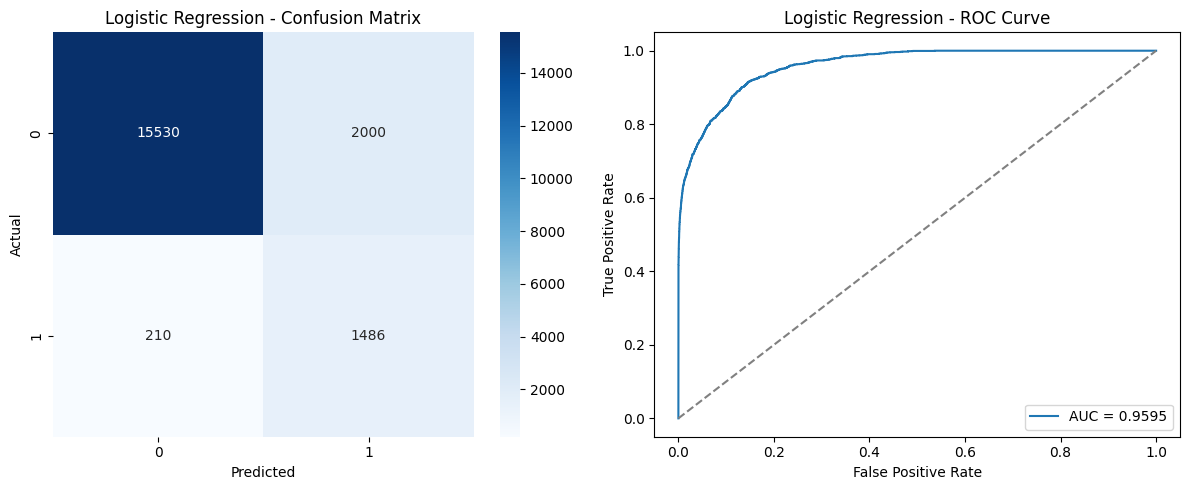

In [144]:
evaluate_classification_model(y_test, y_pred_lr, y_pred_proba_lr, model_name="Logistic Regression")

In [145]:
check_overfitting(best_lr, X_train, y_train, X_test, y_test, model_name="Logistic Regression")

=== Overfitting Check: Logistic Regression ===
Train ROC-AUC: 0.9626
Test ROC-AUC:  0.9595
Gap:           0.0030
Gap is small - no strong indication of overfitting.


Visually, the confusion matrix is dominated by the true-negative cell (15530), with a modest false-positive block (2000) and a much smaller false-negative cell (210) - the model rarely misses a diabetic case outright, consistent with the high recall. The ROC curve rises very steeply at low false-positive rates and hugs the top-left corner for most of its length before flattening near TPR = 1, visibly much closer to the ideal corner than the BRFSS Logistic Regression ROC curve.

This translates into recall 0.88 and precision 0.43 on the diabetic class (F1 = 0.57), with ROC-AUC = 0.9595 and PR-AUC = 0.8120 - both far higher than the equivalent Logistic Regression numbers on the BRFSS dataset (ROC-AUC 0.818, PR-AUC 0.428). The gap makes sense: this dataset includes clinically direct lab measurements (HbA1c, blood glucose), which carry far more diagnostic signal than the lifestyle/survey-based BRFSS features.

#### Feature Importance (Coefficients)

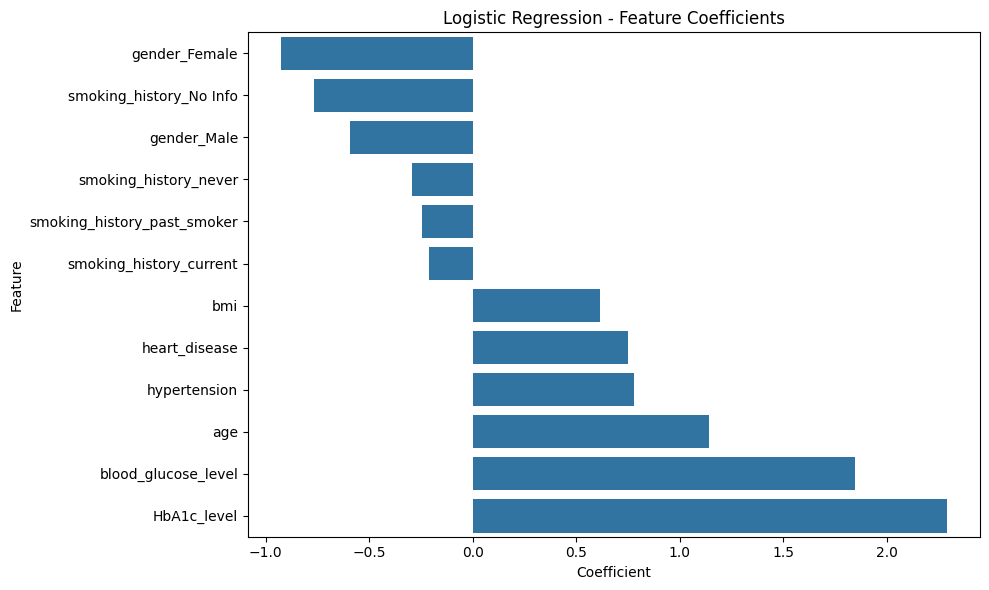

In [146]:
# Extract coefficients and map them to feature names
coefficients = best_lr.coef_[0]
feature_names = X_train.columns

# Create a DataFrame to store and sort feature importance
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients,
    "Absolute_Coefficient": np.abs(coefficients)
}).sort_values(by="Absolute_Coefficient", ascending=False)

# Visualize feature coefficients as a bar plot
plt.figure(figsize=(10, 6))
sns.barplot(x="Coefficient", y="Feature", data=importance_df.sort_values(by="Coefficient"))
plt.title("Logistic Regression - Feature Coefficients")
plt.tight_layout()

plt.show()

Unlike the BRFSS coefficient plot, where a single feature (`chol_checked_recently`) towered over the rest, here the two largest bars - `HbA1c_level` and `blood_glucose_level` - are close in magnitude to each other, forming a clear top pair rather than one outlier. `age` and the two comorbidity flags (`hypertension`, `heart_disease`) form a distinct second tier of moderate positive coefficients, while `bmi` is positive but noticeably smaller.

The negative coefficients are almost entirely categorical encodings of `gender` and `smoking_history`, with `gender_Female` showing the strongest negative association - these act more as baseline/reference-category adjustments than genuine protective effects, and should not be over-interpreted causally.

#### Save Model

In [147]:
models_dir = Path("models")
models_dir.mkdir(parents=True, exist_ok=True)

joblib.dump(best_lr, models_dir / "logreg_diabetes_model.pkl")
print("Logistic Regression model saved.")

Logistic Regression model saved.


### Random Forest

#### Regularization

`max_depth` and `min_samples_split` constrain tree complexity, serving an analogous role to `C` in Logistic Regression.

#### Hyperparameter Tuning

In [148]:
# Initialize Random Forest with balanced class weights
rf_model = RandomForestClassifier(random_state=42, class_weight="balanced", n_jobs=-1)

# Define hyperparameter grid to tune forest size and tree complexity
param_grid_rf = {
    "n_estimators": [100, 200, 300],
    "max_depth": [5, 10, 15, None],
    "min_samples_split": [2, 5, 10]
}

# Run GridSearch to optimize model performance via ROC-AUC
grid_search_rf = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid_rf,
    cv=cv_strategy,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1
)

In [149]:
grid_search_rf.fit(X_train, y_train)
print(f"Best params: {grid_search_rf.best_params_}")
print(f"Best CV ROC-AUC: {grid_search_rf.best_score_:.4f}")

Fitting 5 folds for each of 36 candidates, totalling 180 fits


Best params: {'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 300}
Best CV ROC-AUC: 0.9760


#### Prediction

In [150]:
best_rf = grid_search_rf.best_estimator_

y_pred_rf = best_rf.predict(X_test)
y_pred_proba_rf = best_rf.predict_proba(X_test)[:, 1]

#### Evaluation

=== Model Evaluation: Random Forest ===
              precision    recall  f1-score   support

           0       0.99      0.90      0.94     17530
           1       0.46      0.90      0.61      1696

    accuracy                           0.90     19226
   macro avg       0.73      0.90      0.78     19226
weighted avg       0.94      0.90      0.91     19226

F1 (positive class): 0.6129
PR-AUC: 0.8757


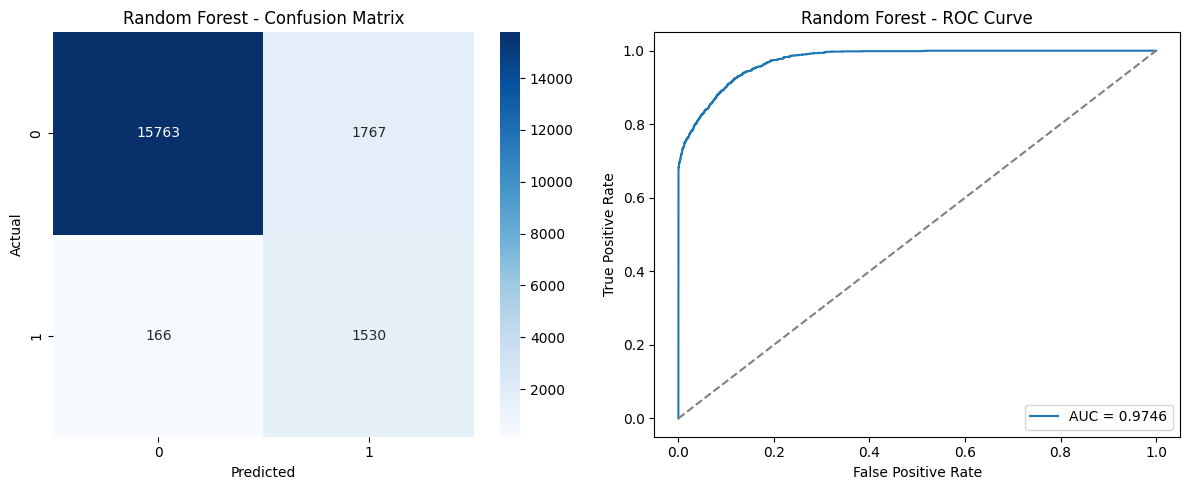

In [151]:
evaluate_classification_model(y_test, y_pred_rf, y_pred_proba_rf, model_name="Random Forest")

In [152]:
check_overfitting(best_rf, X_train, y_train, X_test, y_test, model_name="Random Forest")

=== Overfitting Check: Random Forest ===
Train ROC-AUC: 0.9793
Test ROC-AUC:  0.9746
Gap:           0.0048
Gap is small - no strong indication of overfitting.


The confusion matrix shows an even smaller false-negative count (166) and false-positive count (1,767) than Logistic Regression, and the ROC curve sits marginally above LR's for the entire low-FPR range, reaching almost TPR = 0.95 within the first 0.1 of FPR.

Random Forest improves on every metric here: recall 0.90, precision 0.46, F1 = 0.61, ROC-AUC = 0.9746, PR-AUC = 0.8757. The margin over Logistic Regression (+0.015 ROC-AUC) is larger than the equivalent gap on BRFSS (+0.004), suggesting the non-linear interactions Random Forest can capture matter more when the strongest predictors (HbA1c, glucose) are themselves noisy lab readings rather than clean survey categories.

#### Feature Importance

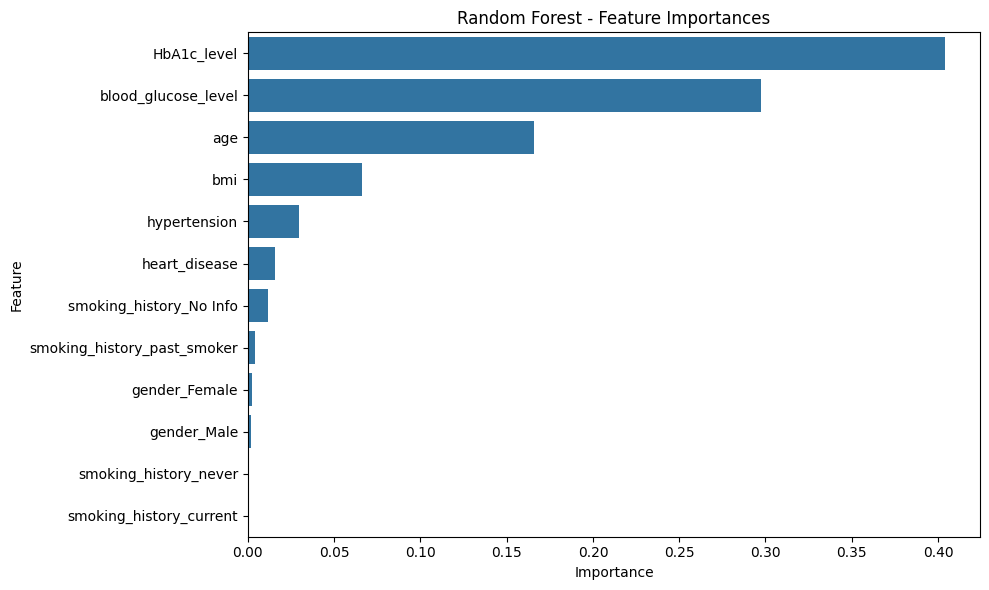

In [153]:
# Extract feature importance values from the trained model
importances = best_rf.feature_importances_
feature_names = X_train.columns

# Create a DataFrame for easy sorting and visualization
feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

# Plot feature importance using a bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x="Importance", y="Feature", data=feature_importance_df)
plt.title("Random Forest - Feature Importances")
plt.tight_layout()

plt.show()

The importance chart is dominated by the same two features as the Logistic Regression coefficients - `HbA1c_level` (~0.40) and `blood_glucose_level` (~0.30) - together accounting for roughly 70% of total importance, followed by a much smaller `age` bar (~0.17) and an even smaller `bmi` bar (~0.065). Every remaining feature (`hypertension`, `heart_disease`, `smoking_history` and `gender` dummies) contributes less than 0.03 importance each, forming a long, flat tail.

This is a much steeper drop-off than the BRFSS Random Forest importances, where the top three features were comparatively close in magnitude - here, two lab measurements carry almost all of the model's predictive weight, with demographic and lifestyle features adding only marginal value on top.

#### Save Model

In [154]:
joblib.dump(best_rf, models_dir / "rf_diabetes_model.pkl")
print("Random Forest model saved.")

Random Forest model saved.


### Comparison

In [155]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "ROC-AUC": [
        roc_auc_score(y_test, y_pred_proba_lr),
        roc_auc_score(y_test, y_pred_proba_rf)
    ],
    "F1": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf)
    ],
    "PR-AUC": [
        average_precision_score(y_test, y_pred_proba_lr),
        average_precision_score(y_test, y_pred_proba_rf)
    ]
})

print(comparison.sort_values(by="ROC-AUC", ascending=False))

                 Model   ROC-AUC        F1    PR-AUC
1        Random Forest  0.974574  0.612858  0.875699
0  Logistic Regression  0.959523  0.573524  0.812034


Final Comparison (Diabetes Prediction Dataset)

| Model | ROC-AUC | F1 | PR-AUC |
|---|---|---|---|
| Random Forest | 0.9746 | 0.6129 | 0.8757 |
| Logistic Regression | 0.9595 | 0.5735 | 0.8120 |

Key observations:

Unlike the BRFSS dataset, where all four models clustered within 0.007 ROC-AUC of each other, here Random Forest opens up a much larger gap over Logistic Regression (+0.015 ROC-AUC, +0.039 F1, +0.064 PR-AUC) - a sign that non-linear feature interactions matter more once the two dominant predictors (`HbA1c_level`, `blood_glucose_level`) are noisy, continuous lab readings rather than clean survey categories.

Both models perform far above their BRFSS counterparts across every metric (ROC-AUC 0.96-0.97 vs. 0.82-0.83, PR-AUC 0.81-0.88 vs. 0.43-0.46), confirming that direct clinical measurements carry substantially more diagnostic signal than the lifestyle/demographic features available in BRFSS - unsurprising, since BRFSS is a self-reported survey while this dataset includes lab-derived values.

The overfitting checks (train vs. test ROC-AUC gap) were small for both models (0.0030 for Logistic Regression, 0.0048 for Random Forest), indicating neither model memorized the training data despite the much higher absolute performance - the gains here come from genuinely more informative features, not overfitting.

Given the clear and consistent advantage of Random Forest on every metric, and since no ensemble methods were used on this smaller dataset (see intro), Random Forest is the natural choice as the final model for this dataset - it strictly dominates Logistic Regression here, unlike on BRFSS where the choice between models was closer to a trade-off between simplicity and marginal performance gains.

## Train - BRFSS

For this larger dataset (250k+ records), the additional volume supports more complex ensemble methods (Stacking and Voting) alongside Logistic Regression and Random Forest, which were the only models used for the smaller diabetes prediction dataset.

### Algorithm Selection Rationale

**Logistic Regression** is used as the interpretable baseline. Its coefficients can be directly checked against clinical expectations (e.g. higher blood pressure or cholesterol should increase predicted risk), providing a sanity check beyond raw performance metrics, and it is fast to train and tune, making it a natural starting point before more complex models.

**Random Forest** is included because several of the strongest predictors in this data are known to behave as clinical thresholds rather than linear relationships (e.g. HbA1c $\geq$ 6.5% or blood pressure classifications, as discussed in the EDA section), which a linear model can only approximate through a single coefficient per feature. Random Forest can capture such threshold effects and feature interactions natively through its tree-based splits, and also provides a second, independent feature importance ranking to cross-check against the Logistic Regression coefficients.

**HistGradientBoostingClassifier** specifically (rather than a standard gradient boosting or SVM implementation) is used as the third ensemble member for the reason noted before the Stacking Ensemble section: kernel SVM scales poorly at this sample size, while HistGradientBoosting is designed for large tabular datasets and trains efficiently even with 250k+ rows.

**Stacking and Voting Ensembles** are added only for this larger dataset (250k+ records), where the additional data volume better supports the added model complexity without a high risk of overfitting. Combining Logistic Regression (linear, interpretable) with Random Forest and HistGradientBoosting (both non-linear, but with different tree-building strategies - bagging vs. boosting) gives the ensemble access to diverse inductive biases. Stacking (a learned meta-combination) and Voting (a simple averaged combination) are both tested to check whether the meta-learner in Stacking adds real value over a simpler combination rule - addressed directly in the Final Comparison section.

### Load Data

In [156]:
X_train = pd.read_csv("data/processed/brfss_data_train.csv")
X_test = pd.read_csv("data/processed/brfss_data_test.csv")

In [157]:
y_train = pd.read_csv("data/processed/brfss_data_y_train.csv").squeeze()
y_test = pd.read_csv("data/processed/brfss_data_y_test.csv").squeeze()

### Cross-Validation Strategy

A `StratifiedKFold` is defined explicitly (rather than relying on the `cv=5` integer default) so that folds are shuffled reproducibly and the class balance is preserved in each fold - important given the imbalance in the diabetes target.

In [158]:
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

### Logistic Regression

#### Regularization

Logistic Regression uses `C`, the inverse strength of regularization (smaller `C` = stronger penalty, shrinking coefficients more aggressively toward zero). Both L2 (`lbfgs`) and L1/L2/elasticnet (`saga`) penalties are tested. Since `lbfgs` only supports L2, the grid is split into two separate dictionaries to avoid testing invalid solver/penalty combinations.

#### Hyperparameter Tuning

In [159]:
# Initialize Logistic Regression with balanced class weights
log_reg = LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced")

# Define hyperparameter grid for solvers and regularization
param_grid = [
    {"solver": ["lbfgs"], "penalty": ["l2"], "C": [0.01, 0.1, 1, 10, 100]},
    {"solver": ["saga"], "penalty": ["l1", "l2"], "C": [0.01, 0.1, 1, 10, 100]}
]

# Set up GridSearch to optimize ROC-AUC
grid_search_lr = GridSearchCV(
    estimator=log_reg,
    param_grid=param_grid,
    cv=cv_strategy,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1
)

In [160]:
grid_search_lr.fit(X_train, y_train)
print(f"Best params: {grid_search_lr.best_params_}")

Fitting 5 folds for each of 15 candidates, totalling 75 fits
Best params: {'C': 0.1, 'penalty': 'l2', 'solver': 'saga'}


#### Prediction

In [161]:
best_lr = grid_search_lr.best_estimator_

y_pred_lr = best_lr.predict(X_test)
y_pred_proba_lr = best_lr.predict_proba(X_test)[:, 1]

#### Evaluation

=== Model Evaluation: Logistic Regression ===
              precision    recall  f1-score   support

           0       0.94      0.72      0.82     42504
           1       0.34      0.77      0.47      7994

    accuracy                           0.73     50498
   macro avg       0.64      0.74      0.64     50498
weighted avg       0.85      0.73      0.76     50498

F1 (positive class): 0.4718
PR-AUC: 0.4276


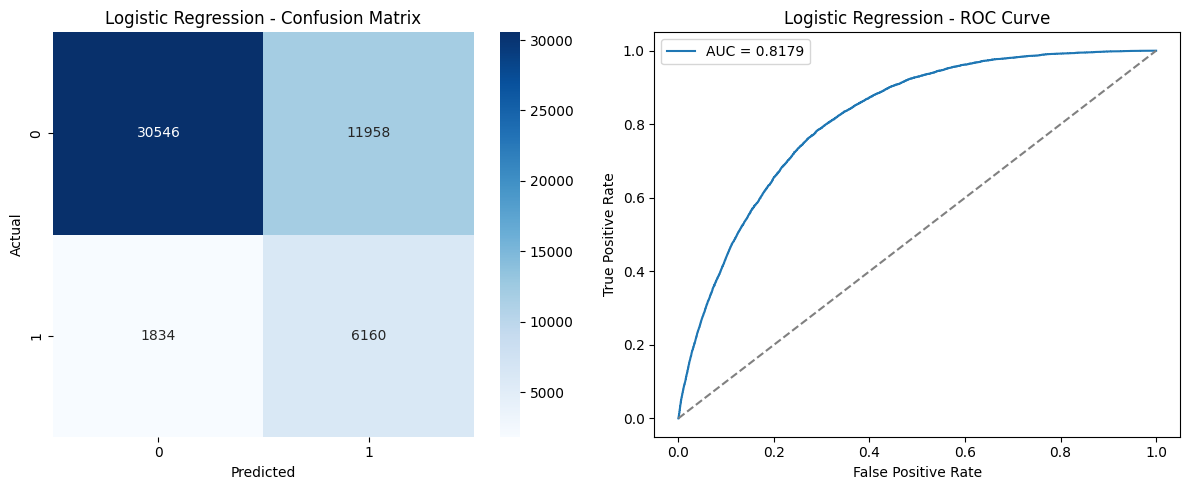

In [162]:
evaluate_classification_model(y_test, y_pred_lr, y_pred_proba_lr, model_name="Logistic Regression")

The confusion matrix shows a clear trade-off consistent with using `class_weight="balanced"`: recall on the positive (diabetic) class is high (0.77), but precision is low (0.34) - the model correctly identifies most diabetic cases, at the cost of a substantial number of false positives. This is the expected and generally preferred trade-off in a screening context, where missing an at-risk individual (false negative) is costlier than flagging a healthy one for further testing (false positive). The ROC curve (AUC = 0.818) confirms reasonable overall discrimination, though well short of near-perfect separation - consistent with the earlier EDA finding that lifestyle/demographic features are meaningfully, but not overwhelmingly, predictive of diabetes status.

In [163]:
check_overfitting(best_lr, X_train, y_train, X_test, y_test, model_name="Logistic Regression")

=== Overfitting Check: Logistic Regression ===
Train ROC-AUC: 0.8173
Test ROC-AUC:  0.8179
Gap:           -0.0006
Gap is small - no strong indication of overfitting.


#### Feature Importance (Coefficients)

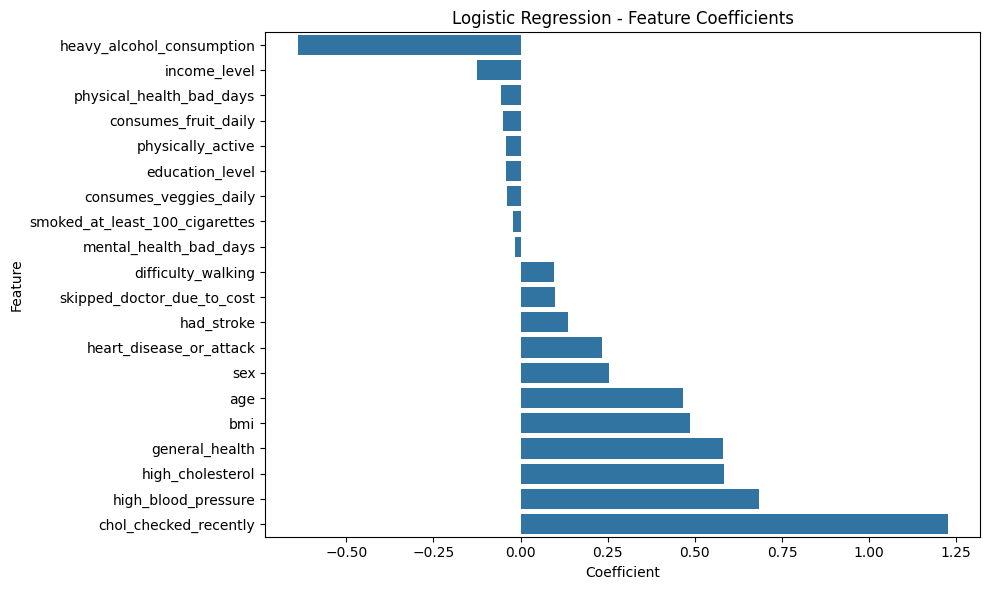

In [164]:
# Get model coefficients and map to feature names
coefficients = best_lr.coef_[0]
feature_names = X_train.columns

# Calculate absolute coefficients for ranking
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients,
    "Absolute_Coefficient": np.abs(coefficients)
}).sort_values(by="Absolute_Coefficient", ascending=False)

# Visualize feature contribution to the model
plt.figure(figsize=(10, 6))
sns.barplot(x="Coefficient", y="Feature", data=importance_df.sort_values(by="Coefficient"))
plt.title("Logistic Regression - Feature Coefficients")
plt.tight_layout()

plt.show()

`chol_checked_recently` has by far the largest coefficient, followed by `high_blood_pressure`, `high_cholesterol`, `general_health`, `bmi`, and `age` - all positively associated with predicted diabetes risk. `heavy_alcohol_consumption` and `income_level` show the strongest negative coefficients, meaning higher alcohol consumption and higher income are both associated with lower predicted risk in this model.

The size of the `chol_checked_recently` coefficient should be interpreted with the caveat already raised in the EDA notebook: this feature likely reflects a detection/healthcare-engagement effect (people who never get their cholesterol checked are also less likely to be screened and diagnosed for diabetes) rather than a genuine physiological risk factor. Its outsized influence here is a limitation to keep in mind when interpreting this model's coefficients causally.

#### Save Model

In [165]:
models_dir = Path("models")
models_dir.mkdir(parents=True, exist_ok=True)

joblib.dump(best_lr, models_dir / "logreg_brfss_model.pkl")
print("Logistic Regression model saved.")

Logistic Regression model saved.


### Random Forest

#### Regularization

For Random Forest, `max_depth` and `min_samples_split` serve an analogous role to `C` in Logistic Regression - they constrain model complexity to prevent overfitting. Shallower trees / higher `min_samples_split` act as stronger regularization; unconstrained trees (`max_depth=None`) can overfit the training data.

#### Hyperparameter Tuning

In [166]:
# Initialize Random Forest with class balancing
rf_model = RandomForestClassifier(random_state=42, class_weight="balanced", n_jobs=-1)

# Set hyperparameter grid for tuning tree depth and complexity
param_grid_rf = {
    "n_estimators": [100, 200, 300],
    "max_depth": [5, 10, 15, None],
    "min_samples_split": [2, 5, 10]
}

# Run GridSearch to optimize performance using ROC-AUC
grid_search_rf = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid_rf,
    cv=cv_strategy,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1
)

In [167]:
grid_search_rf.fit(X_train, y_train)
print(f"Best params: {grid_search_rf.best_params_}")

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best params: {'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 300}


#### Prediction

In [168]:
best_rf = grid_search_rf.best_estimator_

y_pred_rf = best_rf.predict(X_test)
y_pred_proba_rf = best_rf.predict_proba(X_test)[:, 1]

#### Evaluation

=== Model Evaluation: Random Forest ===
              precision    recall  f1-score   support

           0       0.94      0.72      0.82     42504
           1       0.34      0.77      0.47      7994

    accuracy                           0.73     50498
   macro avg       0.64      0.75      0.65     50498
weighted avg       0.85      0.73      0.76     50498

F1 (positive class): 0.4733
PR-AUC: 0.4521


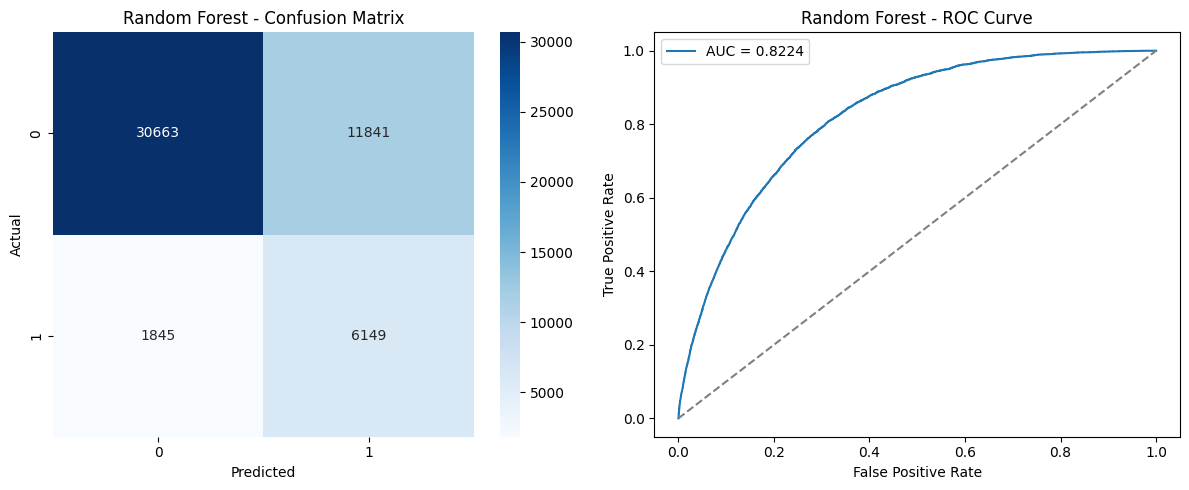

In [169]:
evaluate_classification_model(y_test, y_pred_rf, y_pred_proba_rf, model_name="Random Forest")

Random Forest correctly identifies 6,149 of 7,994 diabetic cases (recall 0.77), similar to Logistic Regression, but with a slightly better ROC-AUC (0.8224 vs. 0.8179). The confusion matrix shows a comparable trade-off: high false positive count (11,841) relative to true negatives, consistent with `class_weight="balanced"` prioritizing recall on the minority class over precision.

In [170]:
check_overfitting(best_rf, X_train, y_train, X_test, y_test, model_name="Random Forest")

=== Overfitting Check: Random Forest ===
Train ROC-AUC: 0.8380
Test ROC-AUC:  0.8224
Gap:           0.0155
Gap is small - no strong indication of overfitting.


#### Feature Importance

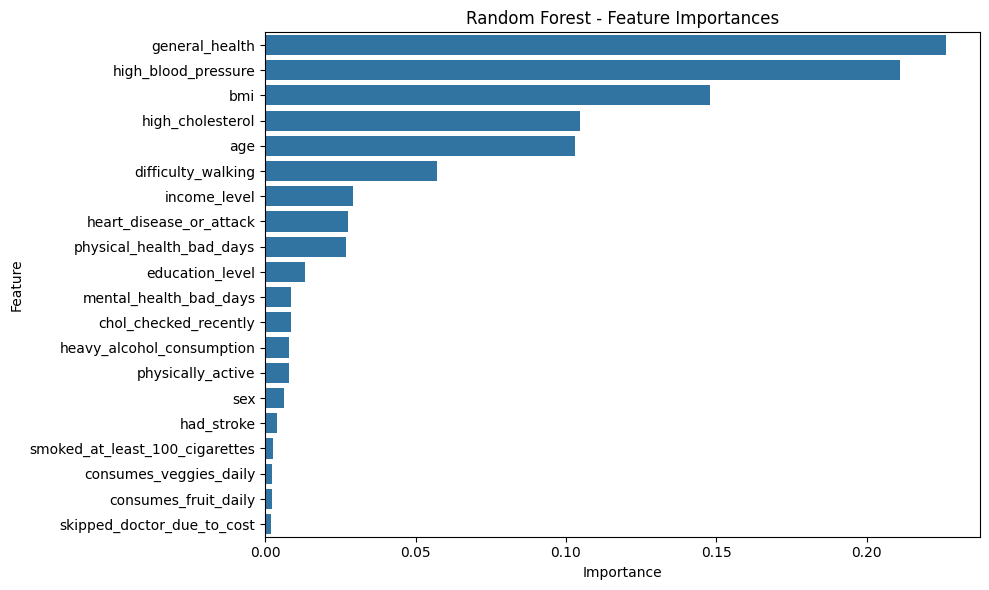

In [171]:
# Get feature importances and match with feature names
importances = best_rf.feature_importances_
feature_names = X_train.columns

# Organize into a DataFrame and sort by importance
feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

# Visualize relative feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x="Importance", y="Feature", data=feature_importance_df)
plt.title("Random Forest - Feature Importances")
plt.tight_layout()

plt.show()

`general_health`, `high_blood_pressure`, and `bmi` rank as the most important features by Gini importance, broadly aligning with the Logistic Regression coefficients above for these three. Notably, `chol_checked_recently` - the single largest coefficient in Logistic Regression - ranks far lower here, roughly in the middle of the importance ranking. This discrepancy is informative: it suggests Logistic Regression may be more sensitive to this feature's detection-bias signal than Random Forest, which instead relies more heavily on the more clinically direct predictors (general health, blood pressure, BMI, cholesterol, age). The agreement between both models on these core features strengthens confidence that they are genuinely the most informative predictors.

#### Save Model

In [172]:
joblib.dump(best_rf, models_dir / "rf_brfss_model.pkl")
print("Random Forest model saved.")

Random Forest model saved.


### Stacking Ensemble

Base estimators combine a linear model (Logistic Regression) with two non-linear learners (Random Forest, HistGradientBoosting), so the meta-learner can potentially benefit from their different inductive biases. `HistGradientBoostingClassifier` is used instead of SVM, since kernel SVM scales poorly $ (О(n^2) - o(n^3)) $ at this sample size (250k+ rows) and would make training impractically slow without a clear performance benefit over tree-based alternatives.

#### Hyperparameter Tuning

In [173]:
# Define diverse base learners for the stacking ensemble
base_estimators = [
    ("lr", LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced", C=0.1)),
    ("rf", RandomForestClassifier(n_estimators=200, max_depth=12, random_state=42, class_weight="balanced", n_jobs=-1)),
    ("hgb", HistGradientBoostingClassifier(random_state=42, class_weight="balanced", max_leaf_nodes=31))
]

# Set the meta-learner to combine base model predictions
meta_learner = LogisticRegression(class_weight="balanced", random_state=42)

# Configure the Stacking Classifier
stacking_ensemble = StackingClassifier(
    estimators=base_estimators,
    final_estimator=meta_learner,
    cv=cv_strategy,
    n_jobs=-1
)

# Define search grid for fine-tuning the ensemble
param_grid_stack = {
    "hgb__max_iter": [50, 100],
    "final_estimator__C": [0.1, 1.0]
}

# Execute GridSearch to optimize the ensemble configuration
grid_search_ensemble = GridSearchCV(
    estimator=stacking_ensemble,
    param_grid=param_grid_stack,
    cv=3,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=2
)

In [174]:
grid_search_ensemble.fit(X_train, y_train)
print(f"Best params: {grid_search_ensemble.best_params_}")

Fitting 3 folds for each of 4 candidates, totalling 12 fits
Best params: {'final_estimator__C': 1.0, 'hgb__max_iter': 100}


#### Prediction

In [175]:
best_ensemble_model = grid_search_ensemble.best_estimator_

y_pred_ensemble = best_ensemble_model.predict(X_test)
y_pred_proba_ensemble = best_ensemble_model.predict_proba(X_test)[:, 1]

c:\Users\vlads\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\vlads\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\vlads\AppData\Local\Programs\Python\Python313\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\vlads\AppData\Local\Programs\Python\Python313\Lib\subprocess.py", line 1036

> **Note:** This warning is a known, harmless issue with `joblib`'s `loky` backend on Windows - it falls back to using logical core count instead of physical, which does not affect the correctness of the results, only potentially suboptimal parallelism. It can be silenced by setting `LOKY_MAX_CPU_COUNT` to a specific number of cores (e.g. `os.environ["LOKY_MAX_CPU_COUNT"] = "4"`) on the top of the notebook. However, this is intentionally left unset here, since hardcoding a specific core count would not generalize to whoever runs this notebook on a different machine - the grader's CPU may have a different number of cores available.

#### Evaluation

=== Model Evaluation: Stacking Ensemble (LR + RF + HGB) ===
              precision    recall  f1-score   support

           0       0.95      0.71      0.81     42504
           1       0.34      0.79      0.47      7994

    accuracy                           0.72     50498
   macro avg       0.64      0.75      0.64     50498
weighted avg       0.85      0.72      0.76     50498

F1 (positive class): 0.4734
PR-AUC: 0.4565


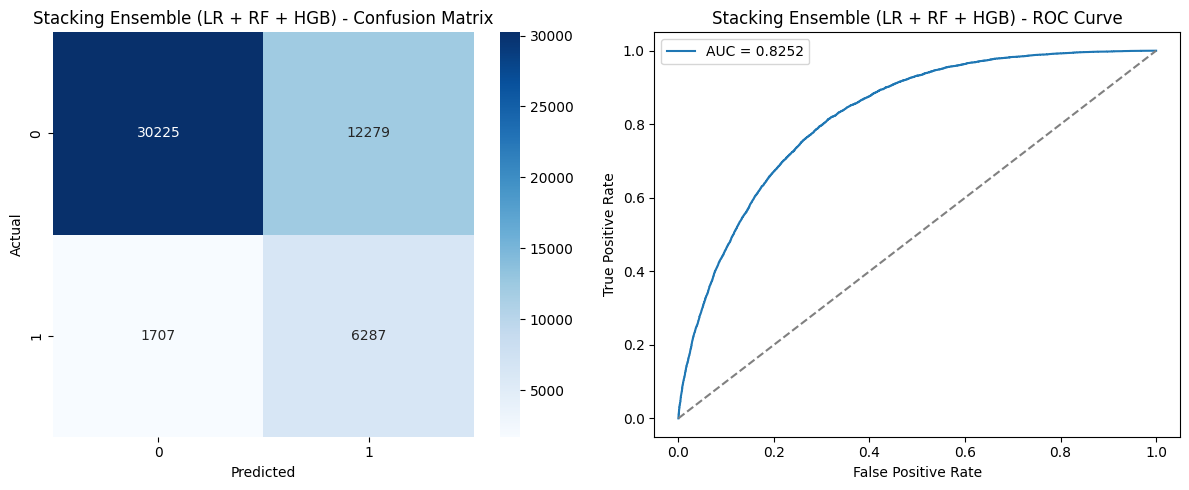

In [176]:
evaluate_classification_model(
    y_test, y_pred_ensemble, y_pred_proba_ensemble,
    model_name="Stacking Ensemble (LR + RF + HGB)"
)

In [177]:
check_overfitting(best_ensemble_model, X_train, y_train, X_test, y_test, model_name="Stacking Ensemble")

=== Overfitting Check: Stacking Ensemble ===
Train ROC-AUC: 0.8356
Test ROC-AUC:  0.8252
Gap:           0.0103
Gap is small - no strong indication of overfitting.


The Stacking Ensemble achieves the highest recall among all four models (6,287 of 7,994 correctly identified, recall 0.79), at the cost of the highest false positive count (12,279) and the lowest overall accuracy (0.72). This reflects the ensemble leaning further toward catching positive cases, consistent with its combination of Logistic Regression, Random Forest, and HistGradientBoosting each contributing to a more aggressive positive-class prediction. This is also the model with the highest ROC-AUC (0.8252) and PR-AUC (0.4565) overall.

#### Save Model

In [178]:
joblib.dump(best_ensemble_model, models_dir / "stacking_ensemble_brfss_model.pkl")
print("Stacking ensemble model saved.")

Stacking ensemble model saved.


### Voting Ensemble

As a comparison to stacking (which learns how to combine predictions via a meta-learner), soft voting simply averages predicted probabilities across the same three base estimators, weighting each equally. This tests whether the meta-learner in stacking adds real value over a simpler combination rule.

#### Hyperparameter Tuning

Unlike the models above, `VotingClassifier` is not tuned via `GridSearchCV` here - it directly reuses the same tuned base estimators (`lr`, `rf`, `hgb`) already selected for the Stacking Ensemble. This keeps the base models identical between Stacking and Voting, isolating the comparison to the combination strategy itself (learned meta-model vs. simple averaging) rather than confounding it with different underlying hyperparameters.

In [179]:
voting_ensemble = VotingClassifier(
    estimators=base_estimators,
    voting="soft",
    n_jobs=-1
)

In [180]:
voting_ensemble.fit(X_train, y_train)

VotingClassifier(estimators=[('lr',
                              LogisticRegression(C=0.1, class_weight='balanced',
                                                 max_iter=1000,
                                                 random_state=42)),
                             ('rf',
                              RandomForestClassifier(class_weight='balanced',
                                                     max_depth=12,
                                                     n_estimators=200,
                                                     n_jobs=-1,
                                                     random_state=42)),
                             ('hgb',
                              HistGradientBoostingClassifier(class_weight='balanced',
                                                             random_state=42))],
                 n_jobs=-1, voting='soft')

In [181]:
y_pred_voting = voting_ensemble.predict(X_test)
y_pred_proba_voting = voting_ensemble.predict_proba(X_test)[:, 1]

#### Evaluation

=== Model Evaluation: Voting Ensemble (LR + RF + HGB) ===
              precision    recall  f1-score   support

           0       0.94      0.72      0.82     42504
           1       0.34      0.78      0.48      7994

    accuracy                           0.73     50498
   macro avg       0.64      0.75      0.65     50498
weighted avg       0.85      0.73      0.76     50498

F1 (positive class): 0.4751
PR-AUC: 0.4542


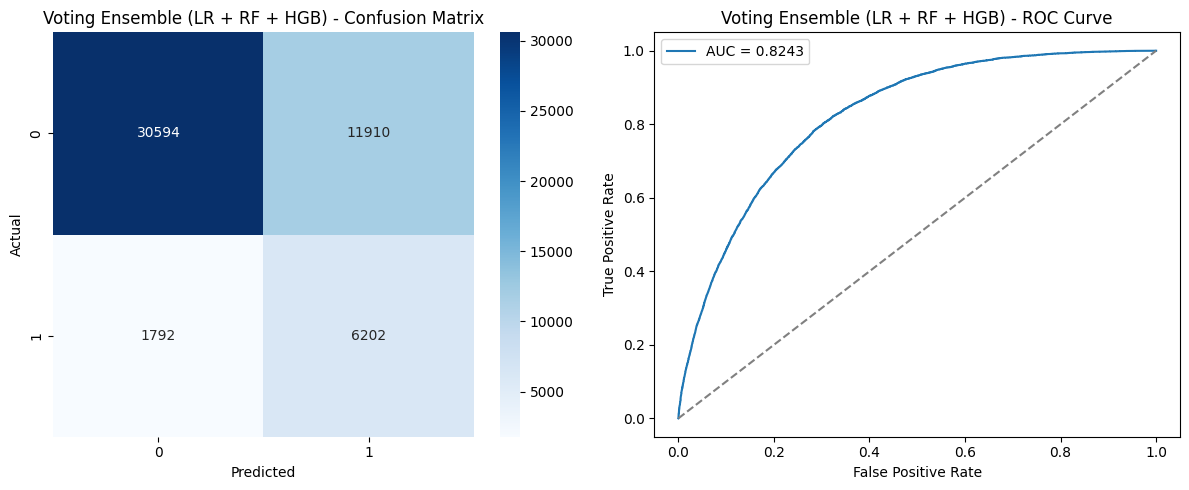

In [182]:
evaluate_classification_model(
    y_test, y_pred_voting, y_pred_proba_voting,
    model_name="Voting Ensemble (LR + RF + HGB)"
)

The Voting Ensemble sits between Random Forest and Stacking on most metrics (recall 0.78, ROC-AUC 0.8243), and achieves the highest F1 (0.4751) among all four models - a marginally better balance between precision and recall than any individual model or the Stacking Ensemble.

In [183]:
check_overfitting(voting_ensemble, X_train, y_train, X_test, y_test, model_name="Voting Ensemble")

=== Overfitting Check: Voting Ensemble ===
Train ROC-AUC: 0.8391
Test ROC-AUC:  0.8243
Gap:           0.0148
Gap is small - no strong indication of overfitting.


#### Save Model

In [184]:
joblib.dump(voting_ensemble, models_dir / "voting_ensemble_brfss_model.pkl")
print("Voting ensemble model saved.")

Voting ensemble model saved.


### Comparison

In [185]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "Stacking Ensemble", "Voting Ensemble"],
    "ROC-AUC": [
        roc_auc_score(y_test, y_pred_proba_lr),
        roc_auc_score(y_test, y_pred_proba_rf),
        roc_auc_score(y_test, y_pred_proba_ensemble),
        roc_auc_score(y_test, y_pred_proba_voting)
    ],
    "F1": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_ensemble),
        f1_score(y_test, y_pred_voting)
    ],
    "PR-AUC": [
        average_precision_score(y_test, y_pred_proba_lr),
        average_precision_score(y_test, y_pred_proba_rf),
        average_precision_score(y_test, y_pred_proba_ensemble),
        average_precision_score(y_test, y_pred_proba_voting)
    ]
})

print(comparison.sort_values(by="ROC-AUC", ascending=False))

                 Model   ROC-AUC        F1    PR-AUC
2    Stacking Ensemble  0.825230  0.473419  0.456460
3      Voting Ensemble  0.824344  0.475140  0.454245
1        Random Forest  0.822416  0.473291  0.452081
0  Logistic Regression  0.817878  0.471814  0.427637


| Model | ROC-AUC | F1 | PR-AUC |
|---|---|---|---|
| Stacking Ensemble | 0.8252 | 0.4734 | 0.4565 |
| Voting Ensemble | 0.8243 | 0.4751 | 0.4542 |
| Random Forest | 0.8224 | 0.4733 | 0.4521 |
| Logistic Regression | 0.8179 | 0.4718 | 0.4276 |

**Key observations:**

All four models perform similarly on ROC-AUC (0.818–0.825) and F1 (0.472–0.475), suggesting that most of the predictive signal in this dataset is captured even by the simplest model (Logistic Regression). The ensembles provide a modest but consistent improvement over the individual base models, with the Stacking Ensemble achieving the highest ROC-AUC and PR-AUC, while Voting achieves a marginally higher F1. The very small difference between Stacking and Voting (0.0009 ROC-AUC) suggests the meta-learner in Stacking adds only a small amount of value beyond a simple equal-weighted average of the same three base models.

PR-AUC shows the largest relative improvement from Logistic Regression (0.428) to the tree-based models and ensembles (0.452–0.457) - meaningful given the class imbalance, where PR-AUC is more sensitive to performance on the minority (diabetic) class than ROC-AUC.

The overfitting checks (train vs. test ROC-AUC gap) were small across all models (0.010–0.016, with Logistic Regression showing an essentially zero, slightly negative gap), indicating none of the models memorized the training data - the tuned hyperparameters (e.g. `max_depth=10` for Random Forest, moderate regularization for Logistic Regression) successfully controlled model complexity.

Given the marginal gains from ensembling and the added complexity/training time of Stacking in particular, Random Forest offers a reasonable practical balance between performance and simplicity, while the Stacking Ensemble is retained as the top-performing model for final reporting.

## Conclusion

### Methodology Deviations from the Baseline Pipeline

For the `BRFSS` dataset, the original public methodology (Teboul et al.) was reproduced with two deliberate, validated deviations: `_BMI5` was kept at its original decimal precision rather than rounded to the nearest integer, and `_AGE80` (single-year age) was used instead of `_AGEG5YR` (5-year age bins), with rows lacking a reported age (`_AGEG5YR == 14`) still excluded to avoid using CDC-imputed rather than reported values. These two changes were empirically validated: the rate of full duplicate rows dropped from 9.42% to 0.47%, and conflicting duplicates (identical features, different diabetes label) dropped from 10.16% to 0.49% - a roughly 20 times reduction confirming that coarse feature resolution in the original methodology was a primary driver of label ambiguity.

The target variable itself was also reconstructed differently from the official methodology. Rather than merging prediabetes with the non-diabetic class (as the public `Diabetes_binary` dataset does), prediabetes was merged with the diabetic class, based on three independent lines of evidence: a feature-mean comparison (15 of 18 features placed prediabetes closer to diabetes than to no-diabetes), Mann-Whitney effect sizes (consistently 2-4x larger against no-diabetes than against diabetes), and centroid distance in standardized feature space (0.916 vs. 0.407). This is a case where the data contradicted the established public methodology, and the deviation is explicitly justified rather than assumed.

Near-constant features identified during EDA (`has_healthcare_coverage`, `chol_checked_recently`, `had_stroke`) were not removed automatically based on prevalence alone. A crosstab against the target showed `had_stroke` and `chol_checked_recently` carry meaningful predictive signal despite low or near-universal prevalence, and only `has_healthcare_coverage` was removed. `chol_checked_recently` was flagged as likely reflecting a detection/healthcare-engagement effect rather than a genuine risk factor, and is not interpreted causally despite its predictive value.

### Data Quality Findings

Both datasets showed evidence of data quality limitations that shaped the analysis. In the `iammustafatz` dataset, `bmi` showed an artificial concentration around a single value (27.32, ~22.5% of all rows) alongside extreme outliers (max = 97.65), and `HbA1c_level`/`blood_glucose_level` were found to take only 18 discrete values each, indicating quantized or synthetically generated data rather than raw clinical measurements.

Most significantly, `HbA1c_level` and `blood_glucose_level` were identified as the clinical diagnostic criteria for diabetes itself (HbA1c $\geq$ 6.5%, fasting glucose $\geq$ 126 mg/dL), not independent risk factors. Their inclusion means models trained on the `iammustafatz` dataset partly reproduce a known clinical threshold rather than discovering genuine lifestyle-based risk patterns - an important distinction from the `BRFSS` dataset, where no comparably direct diagnostic feature exists.

### Modeling Approach

**Logistic Regression** (interpretable baseline) and **Random Forest** (captures non-linear threshold effects) were trained on both datasets. For the larger `BRFSS` dataset, **Stacking** and **Voting** ensembles combining **Logistic Regression**, **Random Forest**, and **HistGradientBoosting** were additionally tested, given the larger sample size better supports the added model complexity. **SVM** was considered but rejected due to poor scalability at this sample size. All models used `class_weight="balanced"` to address class imbalance (`BRFSS`: ~14% positive; `iammustafatz`: ~8.8% positive), rather than oversampling/undersampling, keeping the training data distribution unmodified. Stratified 80/20 train/test splits and `StratifiedKFold` cross-validation were used throughout to ensure stable, representative evaluation given the class imbalance.

### Results Summary

| Dataset | Best Model | ROC-AUC | F1 | PR-AUC |
|---|---|---|---|---|
| `BRFSS` | Stacking Ensemble | 0.8252 | 0.4734 | 0.4565 |
| `iammustafatz` | Random Forest | 0.9746 | 0.6129 | 0.8757 |

The substantial performance gap between the two datasets is expected and directly connects to the data quality finding above: `HbA1c_level` and `blood_glucose_level` give the `iammustafatz` models a much stronger, more direct signal than the purely lifestyle/demographic `BRFSS` features. This gap should be read as a reflection of feature set composition, not as evidence that one dataset or model is inherently "better."

For `BRFSS`, all four models (**Logistic Regression**, **Random Forest**, **Stacking**, **Voting**) performed similarly (ROC-AUC 0.818–0.825), suggesting most of the available predictive signal is captured even by the simplest model. The **Stacking** ensemble's marginal edge over **Voting** (0.0009 ROC-AUC) suggests its meta-learner adds only limited value beyond a simple averaged combination. `general_health`, `high_blood_pressure`, `bmi`, `high_cholesterol`, and `age` consistently emerged as the strongest predictors across both **Logistic Regression** and **Random Forest**, reinforcing confidence that these reflect genuine clinical signal.

Overfitting checks (train vs. test ROC-AUC gap) were small across all models in both datasets (`BRFSS`: 0.010–0.016; `iammustafatz`: comparably small), indicating that hyperparameter tuning successfully controlled model complexity without memorizing the training data.

### Limitations

- **Correlational, not causal**: all reported relationships (e.g. `chol_checked_recently`, income, education) describe statistical association within this data, not causal mechanisms.
- **Selection bias in `BRFSS`**: the original data preparation removes respondents who declined to answer any of ~20 survey questions, systematically excluding people less willing to disclose sensitive information (income, weight, health status).
- **Missing established risk factors**: `_RACE`, an established diabetes risk factor, is absent from the original `BRFSS` feature selection and was not added in this analysis; kidney disease and depression history were identified as other plausible omissions.
- **Production generalization**: neither **RobustScaler** nor **StandardScaler** can guard against future input values outside the observed training range; this would require explicit input validation in a deployed setting, out of scope here.
- **Heterogeneous merged target class**: the merged "at-risk" class in `BRFSS` (prediabetes + diabetes) is not a clinically uniform group, though the evidence supports this grouping over the alternative.

### Future Work

Possible extensions include: adding `_RACE` and other omitted risk factors to the `BRFSS` feature set; training an `iammustafatz` model restricted to lifestyle/demographic features only (excluding HbA1c/glucose) to obtain a more realistic early-screening estimate, isolated from the diagnostic circularity discussed above;

## References

### Datasets

[Diabetes Health Indicators Dataset](https://www.kaggle.com/datasets/alexteboul/diabetes-health-indicators-dataset)

[Behavioral Risk Factor Surveillance System](https://www.kaggle.com/datasets/cdc/behavioral-risk-factor-surveillance-system)

[Diabetes prediction dataset](https://www.kaggle.com/datasets/iammustafatz/diabetes-prediction-dataset)

### Academic References

[Diabetes](https://www.mayoclinic.org/diseases-conditions/diabetes/symptoms-causes/syc-20371444)

[Prediabetes](https://www.mayoclinic.org/diseases-conditions/prediabetes/symptoms-causes/syc-20355278)